# Comprehensive Model Comparison for Genetic Variant Pathogenicity Prediction

## Deney Matrisi: 4 Model × 2 Mod × 2 FE Durumu = 32 Konfigürasyon

| Model | Single-Panel (No-FE) | Single-Panel (FE) | Multi-Panel (No-FE) | Multi-Panel (FE) |
|-------|---------------------|-------------------|--------------------|--------------------|
| **LightGBM** | ✓ (×3 panel) | ✓ (×3 panel) | ✓ | ✓ |
| **XGBoost** | ✓ (×3 panel) | ✓ (×3 panel) | ✓ | ✓ |
| **Neural Network** | ✓ (×3 panel) | ✓ (×3 panel) | ✓ | ✓ |
| **Deep Neural Network** | ✓ (×3 panel) | ✓ (×3 panel) | ✓ | ✓ |

**Paneller**: General, Hereditary_Cancer, PAH (CFTR tek sınıflı → single-panel'da atlanır, multi-panel'da dahil)

**Metrikler**: F1, AUC-ROC, AUC-PR, MCC, Precision, Recall, Specificity, Balanced Accuracy, Cohen's Kappa

---

### İçindekiler
1. Kurulum & Veri Yükleme
2. Veri Hazırlama Fonksiyonları (No-FE / With-FE)
3. Model Builder'lar (LightGBM / XGBoost / NN / DNN)
4. Değerlendirme Çerçevesi
5. Ana Eğitim Döngüsü
6. Sonuç Toplama & Pivot Tablolar
7. Görselleştirmeler (11 farklı grafik tipi)
8. Final Rapor & Model Export

In [1]:
# =============================================================================
# BOLUM 1 - Cell 1: Kutuphaneler ve Sabitler
# =============================================================================
import subprocess, sys

# Gerekli paketleri kur (zaten kuruluysa atlar)
for pkg in ['xgboost', 'shap', 'torch-directml']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import optuna
import torch
import torch_directml
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import time
import warnings
import json
from copy import deepcopy

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score, matthews_corrcoef,
    precision_score, recall_score, balanced_accuracy_score, cohen_kappa_score,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from torch.utils.data import DataLoader, TensorDataset

# Uyarilari kapat
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Sabitler ---
SEED = 42
TRIALS_TREE = 200    # LightGBM ve XGBoost icin Optuna trial sayisi
TRIALS_NN = 100      # NN ve DNN icin Optuna trial sayisi
TEST_SIZE = 0.2
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- GPU Ayarlari (AMD DirectML) ---
try:
    DEVICE = torch_directml.device()
    print(f"AMD GPU (DirectML) aktif: {DEVICE}")
except Exception:
    DEVICE = torch.device('cpu')
    print(f"GPU bulunamadi, CPU kullaniliyor: {DEVICE}")

# --- Panel Ayarlari ---
PANELS_SINGLE = ['General', 'Hereditary_Cancer', 'PAH']  # CFTR haric (tek sinifli)

print(f"Optuna trial sayisi: Agac={TRIALS_TREE}, NN={TRIALS_NN}")
print(f"Test boyutu: {TEST_SIZE}")
print(f"Random seed: {SEED}")

c:\Users\ahmet.ceyhan23\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AMD GPU (DirectML) aktif: privateuseone:0
Optuna trial sayisi: Agac=200, NN=100
Test boyutu: 0.2
Random seed: 42


In [2]:
# =============================================================================
# BOLUM 1 - Cell 2: Veri Yukleme ve Kesfif
# =============================================================================
df_raw = pd.read_csv("open_cravat_curation_v2_imputed.csv")
print(f"Veri boyutu: {df_raw.shape[0]} satir x {df_raw.shape[1]} sutun")

# Panel dagilimi
print(f"\n--- Panel Dagilimi ---")
panel_counts = df_raw['Panel'].value_counts()
for panel, count in panel_counts.items():
    target_dist = df_raw[df_raw['Panel'] == panel]['target'].value_counts()
    n_pos = target_dist.get(1, 0)
    n_neg = target_dist.get(0, 0)
    print(f"  {panel:<25} n={count:>5}  |  Benign={n_neg:>4} ({n_neg/count*100:.1f}%)  Pathogenic={n_pos:>4} ({n_pos/count*100:.1f}%)")

# Genel target dagilimi
print(f"\n--- Genel Target Dagilimi ---")
print(f"  Benign (0):     {(df_raw['target']==0).sum():>5} ({(df_raw['target']==0).mean()*100:.1f}%)")
print(f"  Pathogenic (1): {(df_raw['target']==1).sum():>5} ({(df_raw['target']==1).mean()*100:.1f}%)")

# Sutun tipleri
print(f"\n--- Sutun Tipleri ---")
print(f"  Sayisal: {len(df_raw.select_dtypes(include=[np.number]).columns)}")
print(f"  Kategorik/Object: {len(df_raw.select_dtypes(include=['object']).columns)}")
print(f"  Boolean: {len(df_raw.select_dtypes(include=['bool']).columns)}")
print(f"  Eksik deger: {df_raw.isnull().sum().sum()}")

Veri boyutu: 4287 satir x 119 sutun

--- Panel Dagilimi ---
  General                   n= 3156  |  Benign=2183 (69.2%)  Pathogenic= 973 (30.8%)
  Hereditary_Cancer         n=  715  |  Benign= 518 (72.4%)  Pathogenic= 197 (27.6%)
  PAH                       n=  324  |  Benign= 219 (67.6%)  Pathogenic= 105 (32.4%)
  CFTR                      n=   92  |  Benign=   0 (0.0%)  Pathogenic=  92 (100.0%)

--- Genel Target Dagilimi ---
  Benign (0):      2920 (68.1%)
  Pathogenic (1):  1367 (31.9%)

--- Sutun Tipleri ---
  Sayisal: 89
  Kategorik/Object: 28
  Boolean: 2
  Eksik deger: 0


In [3]:
# =============================================================================
# BOLUM 2 - Cell 3: No-FE Veri Hazirlama Fonksiyonu
# =============================================================================

def prepare_data_no_fe(df):
    """
    Minimal veri hazirlama: sadece gerekli sutunlari dusur, sekans verilerini k-mer ile kodla.
    Prediction ve rankscore sutunlari KORUNUR (gercek ham baseline).
    """
    df = df.copy()
    
    # 1. Bilgi sizintisi / metadata sutunlarini dusur
    leak_cols = ['clinvar__sig', 'clinvar__id', 'Germline review status', 'Stars']
    df.drop(columns=[c for c in leak_cols if c in df.columns], inplace=True)
    
    # 2. Yuksek kardinalite ID sutunlarini dusur (her varyant icin benzersiz)
    id_cols = ['base__cchange', 'base__achange', 'base__chrom', 'base__pos',
               'base__ref_base', 'base__alt_base', 'ref_amino', 'alt_amino',
               'alphamissense__protein_variant']
    df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)
    
    # 3. Boolean -> int
    for col in ['polarity_change', 'chirality_shift']:
        if col in df.columns:
            df[col] = df[col].astype(int)
    
    # 4. Sekans verilerini k-mer frekanslarina donustur
    #    max_features=200 ve min_df=3 ile feature patlamasini onle
    seq_columns = ['Ref_Sequence', 'Alt_Sequence', 'DNA_11mer_Ref', 'DNA_11mer_Alt',
                   'Prot_11mer_Ref', 'Prot_11mer_Alt']
    seq_features_list = []
    
    for col in seq_columns:
        if col in df.columns:
            vectorizer = CountVectorizer(
                analyzer='char', ngram_range=(3, 3),
                max_features=200, min_df=3
            )
            seq_matrix = vectorizer.fit_transform(df[col].fillna(''))
            feature_names = [f"{col}_{motif}" for motif in vectorizer.get_feature_names_out()]
            seq_df = pd.DataFrame(seq_matrix.toarray(), columns=feature_names, index=df.index)
            seq_features_list.append(seq_df)
            print(f"  {col}: {seq_df.shape[1]} k-mer feature")
    
    # Orijinal sekans metin sutunlarini dusur, k-mer feature'lari ekle
    df.drop(columns=[c for c in seq_columns if c in df.columns], inplace=True)
    if seq_features_list:
        df = pd.concat([df] + seq_features_list, axis=1)
    
    # 5. Kalan object sutunlari -> category
    for col in df.select_dtypes(include=['object']).columns:
        if col != 'Panel':
            df[col] = df[col].astype('category')
    
    print(f"[No-FE] Veri boyutu: {df.shape[0]} x {df.shape[1]}")
    return df

print("prepare_data_no_fe() tanimlandi.")


prepare_data_no_fe() tanimlandi.


In [4]:
# =============================================================================
# BOLUM 2 - Cell 4: With-FE Veri Hazirlama Fonksiyonu
# =============================================================================

# --- Grantham Distance Lookup Tablosu ---
_GRANTHAM_RAW = {
    ('A','R'):112,('A','N'):111,('A','D'):126,('A','C'):195,('A','Q'):91,('A','E'):107,
    ('A','G'):60,('A','H'):86,('A','I'):94,('A','L'):96,('A','K'):106,('A','M'):84,
    ('A','F'):113,('A','P'):27,('A','S'):99,('A','T'):58,('A','W'):148,('A','Y'):112,
    ('A','V'):64,('R','N'):86,('R','D'):96,('R','C'):180,('R','Q'):43,('R','E'):54,
    ('R','G'):125,('R','H'):29,('R','I'):97,('R','L'):102,('R','K'):26,('R','M'):91,
    ('R','F'):97,('R','P'):103,('R','S'):110,('R','T'):71,('R','W'):101,('R','Y'):77,
    ('R','V'):96,('N','D'):23,('N','C'):139,('N','Q'):46,('N','E'):42,('N','G'):80,
    ('N','H'):68,('N','I'):149,('N','L'):153,('N','K'):94,('N','M'):142,('N','F'):158,
    ('N','P'):91,('N','S'):46,('N','T'):65,('N','W'):174,('N','Y'):143,('N','V'):133,
    ('D','C'):154,('D','Q'):61,('D','E'):45,('D','G'):94,('D','H'):81,('D','I'):168,
    ('D','L'):172,('D','K'):101,('D','M'):160,('D','F'):177,('D','P'):108,('D','S'):65,
    ('D','T'):85,('D','W'):181,('D','Y'):160,('D','V'):152,('C','Q'):154,('C','E'):170,
    ('C','G'):159,('C','H'):174,('C','I'):198,('C','L'):198,('C','K'):202,('C','M'):196,
    ('C','F'):205,('C','P'):169,('C','S'):112,('C','T'):149,('C','W'):215,('C','Y'):194,
    ('C','V'):192,('Q','E'):29,('Q','G'):87,('Q','H'):24,('Q','I'):109,('Q','L'):113,
    ('Q','K'):53,('Q','M'):101,('Q','F'):116,('Q','P'):76,('Q','S'):68,('Q','T'):42,
    ('Q','W'):130,('Q','Y'):99,('Q','V'):96,('E','G'):98,('E','H'):40,('E','I'):134,
    ('E','L'):138,('E','K'):56,('E','M'):126,('E','F'):140,('E','P'):93,('E','S'):80,
    ('E','T'):65,('E','W'):152,('E','Y'):122,('E','V'):121,('G','H'):98,('G','I'):135,
    ('G','L'):138,('G','K'):127,('G','M'):127,('G','F'):153,('G','P'):42,('G','S'):56,
    ('G','T'):59,('G','W'):184,('G','Y'):147,('G','V'):109,('H','I'):94,('H','L'):99,
    ('H','K'):32,('H','M'):87,('H','F'):100,('H','P'):77,('H','S'):89,('H','T'):47,
    ('H','W'):115,('H','Y'):83,('H','V'):84,('I','L'):5,('I','K'):102,('I','M'):10,
    ('I','F'):21,('I','P'):95,('I','S'):142,('I','T'):89,('I','W'):61,('I','Y'):33,
    ('I','V'):29,('L','K'):107,('L','M'):15,('L','F'):22,('L','P'):98,('L','S'):145,
    ('L','T'):92,('L','W'):61,('L','Y'):36,('L','V'):32,('K','M'):95,('K','F'):102,
    ('K','P'):103,('K','S'):121,('K','T'):78,('K','W'):110,('K','Y'):85,('K','V'):97,
    ('M','F'):28,('M','P'):87,('M','S'):135,('M','T'):81,('M','W'):67,('M','Y'):36,
    ('M','V'):21,('F','P'):114,('F','S'):155,('F','T'):103,('F','W'):40,('F','Y'):22,
    ('F','V'):50,('P','S'):74,('P','T'):38,('P','W'):147,('P','Y'):110,('P','V'):68,
    ('S','T'):58,('S','W'):177,('S','Y'):144,('S','V'):124,('T','W'):128,('T','Y'):92,
    ('T','V'):69,('W','Y'):37,('W','V'):88,('Y','V'):55,
}
GRANTHAM = {}
for (a, b), v in _GRANTHAM_RAW.items():
    GRANTHAM[(a, b)] = v
    GRANTHAM[(b, a)] = v

# --- BLOSUM62 Lookup Tablosu ---
_BLOSUM62_RAW = {
    ('A','A'):4,('A','R'):-1,('A','N'):-2,('A','D'):-2,('A','C'):0,('A','Q'):-1,('A','E'):-1,
    ('A','G'):0,('A','H'):-2,('A','I'):-1,('A','L'):-1,('A','K'):-1,('A','M'):-1,('A','F'):-2,
    ('A','P'):-1,('A','S'):1,('A','T'):0,('A','W'):-3,('A','Y'):-2,('A','V'):0,
    ('R','R'):5,('R','N'):0,('R','D'):-2,('R','C'):-3,('R','Q'):1,('R','E'):0,('R','G'):-2,
    ('R','H'):0,('R','I'):-3,('R','L'):-2,('R','K'):2,('R','M'):-1,('R','F'):-3,('R','P'):-2,
    ('R','S'):-1,('R','T'):-1,('R','W'):-3,('R','Y'):-2,('R','V'):-3,
    ('N','N'):6,('N','D'):1,('N','C'):-3,('N','Q'):0,('N','E'):0,('N','G'):0,('N','H'):1,
    ('N','I'):-3,('N','L'):-3,('N','K'):0,('N','M'):-2,('N','F'):-3,('N','P'):-2,('N','S'):1,
    ('N','T'):0,('N','W'):-4,('N','Y'):-2,('N','V'):-3,
    ('D','D'):6,('D','C'):-3,('D','Q'):0,('D','E'):2,('D','G'):-1,('D','H'):-1,('D','I'):-3,
    ('D','L'):-4,('D','K'):-1,('D','M'):-3,('D','F'):-3,('D','P'):-1,('D','S'):0,('D','T'):-1,
    ('D','W'):-4,('D','Y'):-3,('D','V'):-3,
    ('C','C'):9,('C','Q'):-3,('C','E'):-4,('C','G'):-3,('C','H'):-3,('C','I'):-1,('C','L'):-1,
    ('C','K'):-3,('C','M'):-1,('C','F'):-2,('C','P'):-3,('C','S'):-1,('C','T'):-1,('C','W'):-2,
    ('C','Y'):-2,('C','V'):-1,
    ('Q','Q'):5,('Q','E'):2,('Q','G'):-2,('Q','H'):0,('Q','I'):-3,('Q','L'):-2,('Q','K'):1,
    ('Q','M'):0,('Q','F'):-3,('Q','P'):-1,('Q','S'):0,('Q','T'):-1,('Q','W'):-2,('Q','Y'):-1,
    ('Q','V'):-2,
    ('E','E'):5,('E','G'):-2,('E','H'):0,('E','I'):-3,('E','L'):-3,('E','K'):1,('E','M'):-2,
    ('E','F'):-3,('E','P'):-1,('E','S'):0,('E','T'):-1,('E','W'):-3,('E','Y'):-2,('E','V'):-2,
    ('G','G'):6,('G','H'):-2,('G','I'):-4,('G','L'):-4,('G','K'):-2,('G','M'):-3,('G','F'):-3,
    ('G','P'):-2,('G','S'):0,('G','T'):-2,('G','W'):-2,('G','Y'):-3,('G','V'):-3,
    ('H','H'):8,('H','I'):-3,('H','L'):-3,('H','K'):-1,('H','M'):-2,('H','F'):-1,('H','P'):-2,
    ('H','S'):-1,('H','T'):-2,('H','W'):-2,('H','Y'):2,('H','V'):-3,
    ('I','I'):4,('I','L'):2,('I','K'):-3,('I','M'):1,('I','F'):0,('I','P'):-3,('I','S'):-2,
    ('I','T'):-1,('I','W'):-3,('I','Y'):-1,('I','V'):3,
    ('L','L'):4,('L','K'):-2,('L','M'):2,('L','F'):0,('L','P'):-3,('L','S'):-2,('L','T'):-1,
    ('L','W'):-2,('L','Y'):-1,('L','V'):1,
    ('K','K'):5,('K','M'):-1,('K','F'):-3,('K','P'):-1,('K','S'):0,('K','T'):-1,('K','W'):-3,
    ('K','Y'):-2,('K','V'):-2,
    ('M','M'):5,('M','F'):0,('M','P'):-2,('M','S'):-1,('M','T'):-1,('M','W'):-1,('M','Y'):-1,
    ('M','V'):1,
    ('F','F'):6,('F','P'):-4,('F','S'):-2,('F','T'):-2,('F','W'):1,('F','Y'):3,('F','V'):-1,
    ('P','P'):7,('P','S'):-1,('P','T'):-1,('P','W'):-4,('P','Y'):-3,('P','V'):-2,
    ('S','S'):4,('S','T'):1,('S','W'):-3,('S','Y'):-2,('S','V'):-2,
    ('T','T'):5,('T','W'):-2,('T','Y'):-2,('T','V'):0,
    ('W','W'):11,('W','Y'):2,('W','V'):-3,
    ('Y','Y'):7,('Y','V'):-1,
    ('V','V'):4,
}
BLOSUM62 = {}
for (a, b), v in _BLOSUM62_RAW.items():
    BLOSUM62[(a, b)] = v
    BLOSUM62[(b, a)] = v


def prepare_data_with_fe(df):
    """
    Biyoinformatik feature engineering pipeline.
    Sekanslardan anlamli ozellikler cikarir, gereksiz sutunlari dusurur.
    """
    df = df.copy()
    
    # 1. Bilgi sizintisi / metadata sutunlarini dusur
    leak_cols = ['clinvar__sig', 'clinvar__id', 'Germline review status', 'Stars']
    df.drop(columns=[c for c in leak_cols if c in df.columns], inplace=True)
    
    # 2. Boolean -> int
    for col in ['polarity_change', 'chirality_shift']:
        if col in df.columns:
            df[col] = df[col].astype(int)
    
    # --- 3. SEKANS TABANLI OZELLIKLER ---
    # CpG bolgesi tespiti
    if 'DNA_11mer_Ref' in df.columns:
        df['is_cpg_site'] = df['DNA_11mer_Ref'].apply(
            lambda s: int(s[5:7] == 'CG' or s[4:6] == 'CG') if isinstance(s, str) and len(s) >= 7 else 0)
        df['gc_content_11mer'] = df['DNA_11mer_Ref'].apply(
            lambda s: (s.count('G') + s.count('C')) / len(s) if isinstance(s, str) and len(s) > 0 else 0.5)
    
    # Transition vs Transversion
    if all(c in df.columns for c in ['base__ref_base', 'base__alt_base']):
        transitions = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
        df['is_transition'] = df.apply(
            lambda r: int((r['base__ref_base'], r['base__alt_base']) in transitions), axis=1)
    
    # --- 4. AMINO ASIT SUBSTITUSYON OZELLIKLERI ---
    if all(c in df.columns for c in ['ref_amino', 'alt_amino']):
        # Grantham Distance
        df['grantham_distance'] = df.apply(
            lambda r: GRANTHAM.get((r['ref_amino'], r['alt_amino']), np.nan)
            if isinstance(r['ref_amino'], str) and isinstance(r['alt_amino'], str)
            and len(r['ref_amino']) == 1 and len(r['alt_amino']) == 1
            else np.nan, axis=1)
        df.loc[df['ref_amino'] == df['alt_amino'], 'grantham_distance'] = 0
        
        # Grantham kategorisi (ACMG uyumlu)
        df['grantham_category'] = pd.cut(
            df['grantham_distance'], bins=[-1, 50, 100, 150, 300],
            labels=[0, 1, 2, 3]).astype(float)
        
        # BLOSUM62
        df['blosum62_score'] = df.apply(
            lambda r: BLOSUM62.get((r['ref_amino'], r['alt_amino']), np.nan)
            if isinstance(r['ref_amino'], str) and isinstance(r['alt_amino'], str)
            and len(r['ref_amino']) == 1 and len(r['alt_amino']) == 1
            else np.nan, axis=1)
    
    # --- 5. gnomAD TUREVLERI ---
    if all(c in df.columns for c in ['gnomad4__ac', 'gnomad4__an']):
        df['gnomad4__af_computed'] = df['gnomad4__ac'] / df['gnomad4__an'].replace(0, np.nan)
    
    if 'gnomad4__af' in df.columns:
        df['log10_af'] = np.log10(df['gnomad4__af'].clip(lower=1e-8))
        df['gnomad4__is_absent'] = (df['gnomad4__af'] == 0).astype(int)
        df['af_bin'] = pd.cut(
            df['gnomad4__af'], bins=[-0.001, 0, 1e-5, 1e-3, 0.01, 1.0],
            labels=[0, 1, 2, 3, 4]).astype(float)
    
    if all(c in df.columns for c in ['gnomad4__nhomalt', 'gnomad4__ac']):
        df['homozygote_ratio'] = df['gnomad4__nhomalt'] / (df['gnomad4__ac'] / 2).replace(0, np.nan)
    
    # --- 6. EVRIMSEL KORUNUM ---
    if all(c in df.columns for c in ['phylop__phylop100_vert', 'phastcons__phastcons100_vert']):
        df['conservation_product'] = df['phylop__phylop100_vert'] * df['phastcons__phastcons100_vert']
    
    # --- 7. CHASMplus: sadece ana skoru tut ---
    chasm_cols = [c for c in df.columns if c.startswith('chasmplus_') and c.endswith('__score') and c != 'chasmplus__score']
    if chasm_cols:
        df.drop(columns=chasm_cols, inplace=True)
    
    # --- 8. ARAC KONSENSUS ---
    pred_cols_map = {
        'esm1b__prediction': ['Damaging'], 'metalr__pred': ['Damaging'],
        'metarnn__pred': ['Damaging'], 'metasvm__pred': ['Damaging'],
        'mistic__pred': ['Pathogenic'], 'mutationtaster__prediction': ['Damaging'],
        'phdsnpg__prediction': ['Pathogenic'], 'provean__prediction': ['Damaging'],
        'sift__prediction': ['Damaging'],
        'alphamissense__am_class': ['likely_pathogenic', 'pathogenic'],
    }
    consensus_sum = pd.Series(0, index=df.index)
    tool_count = 0
    for col, labels in pred_cols_map.items():
        if col in df.columns:
            consensus_sum += df[col].isin(labels).astype(int)
            tool_count += 1
    df['tool_consensus_damaging'] = consensus_sum
    df['tool_consensus_ratio'] = consensus_sum / max(tool_count, 1)
    
    # --- 9. GEREKSIZ SUTUNLARI DUSUR ---
    # Sekans metin sutunlari (bilgileri FE feature'lara aktarildi)
    seq_cols = ['Ref_Sequence', 'Alt_Sequence', 'DNA_11mer_Ref', 'DNA_11mer_Alt',
                'Prot_11mer_Ref', 'Prot_11mer_Alt']
    df.drop(columns=[c for c in seq_cols if c in df.columns], inplace=True)
    
    # Prediction kategorikleri (konsensuse donusturuldu)
    pred_drop = list(pred_cols_map.keys()) + ['alphamissense__protein_variant']
    df.drop(columns=[c for c in pred_drop if c in df.columns], inplace=True)
    
    # Rankscore sutunlari (ham skorlarin monoton donusumu)
    rankscore_cols = [c for c in df.columns if '__rankscore' in c]
    df.drop(columns=rankscore_cols, inplace=True)
    
    # ID sutunlari
    id_cols = ['base__cchange', 'base__achange', 'base__chrom', 'base__pos',
               'base__ref_base', 'base__alt_base', 'ref_amino', 'alt_amino']
    df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)
    
    # --- 10. MINIMAL FILTRELEME ---
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target']
    
    # r > 0.99 kopya filtreleme
    if len(numeric_cols) > 1:
        corr_matrix = df[numeric_cols].corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
        target_corr = df[numeric_cols].corrwith(df['target']).abs()
        to_drop = set()
        for col in upper_tri.columns:
            for idx in upper_tri.index:
                if upper_tri.loc[idx, col] > 0.99 and idx not in to_drop and col not in to_drop:
                    if target_corr.get(idx, 0) >= target_corr.get(col, 0):
                        to_drop.add(col)
                    else:
                        to_drop.add(idx)
        if to_drop:
            df.drop(columns=list(to_drop), inplace=True)
            print(f"  r>0.99 kopya filtreleme: {len(to_drop)} sutun dusuruldu")
    
    # Sifir varyans filtreleme
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target']
    zero_var = [c for c in numeric_cols if df[c].std() == 0]
    if zero_var:
        df.drop(columns=zero_var, inplace=True)
    
    # Kategorik ayarla
    for col in df.select_dtypes(include=['object']).columns:
        if col != 'Panel':
            df[col] = df[col].astype('category')
    
    print(f"[With-FE] Veri boyutu: {df.shape[0]} x {df.shape[1]}")
    return df

print("prepare_data_with_fe() tanimlandi.")

prepare_data_with_fe() tanimlandi.


In [5]:
# =============================================================================
# BOLUM 2 - Cell 5: Veri Bolme ve NN Hazirlama Fonksiyonlari
# =============================================================================

def get_train_test_data(df_prepared, mode, panel=None):
    """
    Verilen mod/panel icin X_train, X_test, y_train, y_test dondurur.
    Kategorik sutunlar icin LabelEncoder da dondurur (XGBoost/NN icin).
    """
    df = df_prepared.copy()
    
    if mode == 'single_panel':
        df = df[df['Panel'] == panel].copy()
        df.drop(columns=['Panel'], inplace=True)
    elif mode == 'multi_panel':
        # Panel'i one-hot encode et
        panel_dummies = pd.get_dummies(df['Panel'], prefix='panel', dtype=int)
        df = pd.concat([df.drop(columns=['Panel']), panel_dummies], axis=1)
    
    X = df.drop(columns=['target'])
    y = df['target']
    
    # Kategorik sutunlari tespit et
    cat_features = X.select_dtypes(include=['category']).columns.tolist()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
    )
    
    return X_train, X_test, y_train, y_test, cat_features


def prepare_for_xgb(X_train, X_test, cat_features):
    """XGBoost icin kategorik sutunlari LabelEncode et."""
    X_tr = X_train.copy()
    X_te = X_test.copy()
    label_encoders = {}
    
    for col in cat_features:
        if col in X_tr.columns:
            le = LabelEncoder()
            # Train + test'teki tum benzersiz degerleri fit et
            all_vals = pd.concat([X_tr[col].astype(str), X_te[col].astype(str)]).unique()
            le.fit(all_vals)
            X_tr[col] = le.transform(X_tr[col].astype(str))
            X_te[col] = le.transform(X_te[col].astype(str))
            label_encoders[col] = le
    
    return X_tr, X_te, label_encoders


def prepare_for_nn(X_train, X_test, y_train, y_test, cat_features):
    """NN/DNN icin StandardScaler + tensor donusumu."""
    X_tr = X_train.copy()
    X_te = X_test.copy()
    
    # Kategorik sutunlari LabelEncode et
    for col in cat_features:
        if col in X_tr.columns:
            le = LabelEncoder()
            all_vals = pd.concat([X_tr[col].astype(str), X_te[col].astype(str)]).unique()
            le.fit(all_vals)
            X_tr[col] = le.transform(X_tr[col].astype(str))
            X_te[col] = le.transform(X_te[col].astype(str))
    
    # Tum sutunlari float'a cevir
    X_tr = X_tr.astype(np.float32)
    X_te = X_te.astype(np.float32)
    
    # NaN'leri 0 ile doldur (NN NaN kabul etmez)
    X_tr = X_tr.fillna(0)
    X_te = X_te.fillna(0)
    
    # StandardScaler
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    # Tensor donusumu
    X_tr_tensor = torch.FloatTensor(X_tr_scaled)
    X_te_tensor = torch.FloatTensor(X_te_scaled)
    y_tr_tensor = torch.FloatTensor(y_train.values)
    y_te_tensor = torch.FloatTensor(y_test.values)
    
    input_dim = X_tr_scaled.shape[1]
    pos_weight = torch.FloatTensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)])
    
    return X_tr_tensor, X_te_tensor, y_tr_tensor, y_te_tensor, input_dim, pos_weight, scaler


def optimize_threshold(y_true, y_prob):
    """F1 score'u maximize eden threshold'u bul."""
    best_thr, best_f1 = 0.5, 0
    for thr in np.arange(0.10, 0.90, 0.01):
        f1_val = f1_score(y_true, (y_prob >= thr).astype(int), zero_division=0)
        if f1_val > best_f1:
            best_f1 = f1_val
            best_thr = thr
    return best_thr, best_f1

print("Veri bolme ve yardimci fonksiyonlar tanimlandi.")

Veri bolme ve yardimci fonksiyonlar tanimlandi.


In [6]:
# =============================================================================
# BOLUM 3 - Cell 6: LightGBM Builder
# =============================================================================

def build_lightgbm(X_train, y_train, X_test, y_test, cat_features, n_trials=TRIALS_TREE):
    """Optuna ile optimize edilmis LightGBM modeli."""
    
    def objective(trial):
        params = {
            'objective': 'binary', 'verbosity': -1, 'random_state': SEED,
            'class_weight': 'balanced',
            'num_leaves': trial.suggest_int('num_leaves', 10, 120),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_child_samples': trial.suggest_int('min_child_samples', 3, 50),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-5, 10.0, log=True),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 800),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'subsample': trial.suggest_float('subsample', 0.3, 1.0),
            'subsample_freq': trial.suggest_int('subsample_freq', 1, 7),
            'max_bin': trial.suggest_int('max_bin', 63, 511),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        }
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        f1_scores = []
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            model = lgb.LGBMClassifier(**params)
            model.fit(X_tr, y_tr, categorical_feature=cat_features)
            y_val_pred = model.predict(X_val)
            f1_scores.append(f1_score(y_val, y_val_pred))
        return np.mean(f1_scores)
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    best_params = study.best_params
    best_params.update({'objective': 'binary', 'verbosity': -1, 'random_state': SEED, 'class_weight': 'balanced'})
    
    best_model = lgb.LGBMClassifier(**best_params)
    best_model.fit(X_train, y_train, categorical_feature=cat_features)
    
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    best_thr, best_f1 = optimize_threshold(y_test, y_pred_proba)
    
    return best_model, study, best_thr, y_pred_proba

print("build_lightgbm() tanimlandi.")

build_lightgbm() tanimlandi.


In [7]:
# =============================================================================
# BOLUM 3 - Cell 7: XGBoost Builder
# =============================================================================

def build_xgboost(X_train, y_train, X_test, y_test, cat_features, n_trials=TRIALS_TREE):
    """Optuna ile optimize edilmis XGBoost modeli."""
    
    # Kategorik sutunlari encode et
    X_tr_enc, X_te_enc, _ = prepare_for_xgb(X_train, X_test, cat_features)
    
    # Sinif orani
    scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    
    def objective(trial):
        params = {
            'objective': 'binary:logistic', 'eval_metric': 'logloss',
            'random_state': SEED, 'verbosity': 0,
            'scale_pos_weight': scale_pos,
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 800),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'subsample': trial.suggest_float('subsample', 0.3, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        f1_scores = []
        for train_idx, val_idx in skf.split(X_tr_enc, y_train):
            X_tr_fold = X_tr_enc.iloc[train_idx]
            X_val_fold = X_tr_enc.iloc[val_idx]
            y_tr_fold = y_train.iloc[train_idx]
            y_val_fold = y_train.iloc[val_idx]
            
            model = xgb.XGBClassifier(**params, use_label_encoder=False)
            model.fit(X_tr_fold, y_tr_fold)
            y_val_pred = model.predict(X_val_fold)
            f1_scores.append(f1_score(y_val_fold, y_val_pred))
        return np.mean(f1_scores)
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    best_params = study.best_params
    best_params.update({
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'random_state': SEED, 'verbosity': 0, 'scale_pos_weight': scale_pos,
        'use_label_encoder': False
    })
    
    best_model = xgb.XGBClassifier(**best_params)
    best_model.fit(X_tr_enc, y_train)
    
    y_pred_proba = best_model.predict_proba(X_te_enc)[:, 1]
    best_thr, best_f1 = optimize_threshold(y_test, y_pred_proba)
    
    return best_model, study, best_thr, y_pred_proba

print("build_xgboost() tanimlandi.")

build_xgboost() tanimlandi.


In [8]:
# =============================================================================
# BOLUM 3 - Cell 8: Shallow MLP (Neural Network) Builder
# =============================================================================

class ShallowMLP(torch.nn.Module):
    """1-2 katmanli MLP: Input -> [Hidden+BN+ReLU+Dropout] x N -> Output(1)"""
    def __init__(self, input_dim, hidden_dim, n_layers, dropout_rate):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            layers.extend([
                torch.nn.Linear(in_dim, hidden_dim),
                torch.nn.BatchNorm1d(hidden_dim),
                torch.nn.ReLU(),
                torch.nn.Dropout(dropout_rate),
            ])
            in_dim = hidden_dim
        layers.append(torch.nn.Linear(in_dim, 1))
        self.network = torch.nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


def _train_nn_model(model_class, X_train, y_train, X_test, y_test, cat_features,
                    n_trials, layer_range, hidden_range, dropout_range):
    """NN/DNN icin ortak egitim fonksiyonu."""
    
    nn_data = prepare_for_nn(X_train, X_test, y_train, y_test, cat_features)
    X_tr_t, X_te_t, y_tr_t, y_te_t, input_dim, pos_weight, scaler = nn_data
    
    def objective(trial):
        n_layers = trial.suggest_int('n_layers', layer_range[0], layer_range[1])
        hidden_dim = trial.suggest_int('hidden_dim', hidden_range[0], hidden_range[1], step=32)
        dropout = trial.suggest_float('dropout', dropout_range[0], dropout_range[1])
        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
        
        # 3-fold CV (hiz icin)
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        f1_scores = []
        
        for train_idx, val_idx in skf.split(X_tr_t.numpy(), y_tr_t.numpy()):
            X_fold_tr = X_tr_t[train_idx]
            y_fold_tr = y_tr_t[train_idx]
            X_fold_val = X_tr_t[val_idx]
            y_fold_val = y_tr_t[val_idx]
            
            model = model_class(input_dim, hidden_dim, n_layers, dropout)
            
            criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            
            dataset = TensorDataset(X_fold_tr, y_fold_tr)
            loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
            
            best_val_f1 = 0
            patience_counter = 0
            
            model.train()
            for epoch in range(100):
                for batch_X, batch_y in loader:
                    optimizer.zero_grad()
                    output = model(batch_X)
                    loss = criterion(output, batch_y)
                    loss.backward()
                    optimizer.step()
                
                # Validation
                model.eval()
                with torch.no_grad():
                    val_logits = model(X_fold_val)
                    val_probs = torch.sigmoid(val_logits).numpy()
                    val_preds = (val_probs >= 0.5).astype(int)
                    val_f1 = f1_score(y_fold_val.numpy(), val_preds)
                
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= 15:
                        break
                model.train()
            
            f1_scores.append(best_val_f1)
        
        return np.mean(f1_scores)
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    # En iyi parametrelerle final modeli egit
    bp = study.best_params
    final_model = model_class(input_dim, bp['hidden_dim'], bp['n_layers'], bp['dropout'])
    
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(final_model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
    
    dataset = TensorDataset(X_tr_t, y_tr_t)
    loader = DataLoader(dataset, batch_size=bp['batch_size'], shuffle=True)
    
    final_model.train()
    best_val_f1 = 0
    patience_counter = 0
    best_state = None
    
    for epoch in range(150):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            output = final_model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
        
        final_model.eval()
        with torch.no_grad():
            val_logits = final_model(X_te_t)
            val_probs = torch.sigmoid(val_logits).numpy()
            val_f1 = f1_score(y_te_t.numpy(), (val_probs >= 0.5).astype(int))
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = deepcopy(final_model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                break
        final_model.train()
    
    if best_state is not None:
        final_model.load_state_dict(best_state)
    
    final_model.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(final_model(X_te_t)).numpy()
    
    best_thr, best_f1 = optimize_threshold(y_test, y_pred_proba)
    
    return final_model, study, best_thr, y_pred_proba


def build_nn(X_train, y_train, X_test, y_test, cat_features, n_trials=TRIALS_NN):
    """Optuna ile optimize edilmis Shallow MLP."""
    return _train_nn_model(
        ShallowMLP, X_train, y_train, X_test, y_test, cat_features,
        n_trials=n_trials, layer_range=(1, 2), hidden_range=(32, 256), dropout_range=(0.1, 0.5)
    )

print("build_nn() (Shallow MLP) tanimlandi.")

build_nn() (Shallow MLP) tanimlandi.


In [9]:
# =============================================================================
# BOLUM 3 - Cell 9: Deep MLP (Deep Neural Network) Builder
# =============================================================================

class DeepMLP(torch.nn.Module):
    """3-5 katmanli MLP: Residual-like connections + LR scheduling destegi."""
    def __init__(self, input_dim, hidden_dim, n_layers, dropout_rate):
        super().__init__()
        self.input_proj = torch.nn.Linear(input_dim, hidden_dim)
        self.input_bn = torch.nn.BatchNorm1d(hidden_dim)
        
        self.blocks = torch.nn.ModuleList()
        for i in range(n_layers):
            block = torch.nn.Sequential(
                torch.nn.Linear(hidden_dim, hidden_dim),
                torch.nn.BatchNorm1d(hidden_dim),
                torch.nn.ReLU(),
                torch.nn.Dropout(dropout_rate),
            )
            self.blocks.append(block)
        
        self.output = torch.nn.Linear(hidden_dim, 1)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(dropout_rate * 0.5)
    
    def forward(self, x):
        x = self.dropout(self.relu(self.input_bn(self.input_proj(x))))
        for i, block in enumerate(self.blocks):
            residual = x
            x = block(x)
            if i % 2 == 1:  # Her 2 katmanda bir residual connection
                x = x + residual
        return self.output(x).squeeze(-1)


def build_dnn(X_train, y_train, X_test, y_test, cat_features, n_trials=TRIALS_NN):
    """Optuna ile optimize edilmis Deep MLP."""
    return _train_nn_model(
        DeepMLP, X_train, y_train, X_test, y_test, cat_features,
        n_trials=n_trials, layer_range=(3, 5), hidden_range=(64, 512), dropout_range=(0.2, 0.6)
    )

print("build_dnn() (Deep MLP) tanimlandi.")

build_dnn() (Deep MLP) tanimlandi.


In [10]:
# =============================================================================
# BOLUM 4 - Cell 10: Metrik Hesaplama Fonksiyonu
# =============================================================================

def compute_all_metrics(y_true, y_pred, y_prob):
    """9 kapsamli metrik hesapla."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    metrics = {
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc_roc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0,
        'auc_pr': average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0,
        'mcc': matthews_corrcoef(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohens_kappa': cohen_kappa_score(y_true, y_pred),
    }
    return metrics

print("compute_all_metrics() tanimlandi.")

compute_all_metrics() tanimlandi.


In [11]:
# =============================================================================
# BOLUM 4 - Cell 11: Tek Konfigurasyon Calistirici
# =============================================================================

MODEL_BUILDERS = {
    'lightgbm': build_lightgbm,
    'xgboost': build_xgboost,
    'nn': build_nn,
    'dnn': build_dnn,
}

def run_single_config(config, df_no_fe, df_with_fe):
    """Tek bir konfigurasyonu bastan sona calistir."""
    config_id = config['config_id']
    model_type = config['model_type']
    fe_state = config['fe_state']
    mode = config['mode']
    panel = config.get('panel', None)
    
    # Dogru veriyi sec
    df_prepared = df_with_fe if fe_state == 'with_fe' else df_no_fe
    
    # Veriyi bol
    X_train, X_test, y_train, y_test, cat_features = get_train_test_data(
        df_prepared, mode, panel
    )
    
    print(f"  Veri: {X_train.shape[0]} train, {X_test.shape[0]} test, {X_train.shape[1]} feature")
    
    # Model kur
    builder = MODEL_BUILDERS[model_type]
    model, study, best_thr, y_pred_proba = builder(
        X_train, y_train, X_test, y_test, cat_features
    )
    
    # Metrik hesapla (optimize edilmis threshold ile)
    y_pred = (y_pred_proba >= best_thr).astype(int)
    metrics = compute_all_metrics(y_test, y_pred, y_pred_proba)
    
    # Varsayilan threshold (0.5) ile de hesapla
    y_pred_default = (y_pred_proba >= 0.5).astype(int)
    f1_default = f1_score(y_test, y_pred_default, zero_division=0)
    
    result = {
        'config_id': config_id,
        'model_type': model_type,
        'fe_state': fe_state,
        'mode': mode,
        'panel': panel if panel else 'All',
        'best_threshold': best_thr,
        'f1_default': f1_default,
        'best_cv_f1': study.best_value,
        'n_train': X_train.shape[0],
        'n_test': X_test.shape[0],
        'n_features': X_train.shape[1],
        # Metrikler
        **metrics,
        # Model ve tahminler (gorsellestirme icin)
        '_model': model,
        '_study': study,
        '_y_test': y_test.values,
        '_y_pred_proba': y_pred_proba,
        '_y_pred': y_pred,
        '_feature_names': list(X_train.columns) if hasattr(X_train, 'columns') else None,
    }
    
    return result

print("run_single_config() tanimlandi.")

run_single_config() tanimlandi.


In [12]:
# =============================================================================
# BOLUM 5 - Cell 12: Veri Hazirligi (bir kez calisir)
# =============================================================================
print("No-FE verisi hazirlaniyor...")
df_no_fe = prepare_data_no_fe(df_raw.copy())

print("\nWith-FE verisi hazirlaniyor...")
df_with_fe = prepare_data_with_fe(df_raw.copy())

print(f"\n{'='*60}")
print(f"No-FE:    {df_no_fe.shape[0]} x {df_no_fe.shape[1]}")
print(f"With-FE:  {df_with_fe.shape[0]} x {df_with_fe.shape[1]}")
print(f"{'='*60}")

No-FE verisi hazirlaniyor...
  Ref_Sequence: 64 k-mer feature
  Alt_Sequence: 64 k-mer feature
  DNA_11mer_Ref: 64 k-mer feature
  DNA_11mer_Alt: 64 k-mer feature
  Prot_11mer_Ref: 200 k-mer feature
  Prot_11mer_Alt: 200 k-mer feature
[No-FE] Veri boyutu: 4287 x 756

With-FE verisi hazirlaniyor...
  r>0.99 kopya filtreleme: 4 sutun dusuruldu
[With-FE] Veri boyutu: 4287 x 55

No-FE:    4287 x 756
With-FE:  4287 x 55


In [13]:
# =============================================================================
# BOLUM 5 - Cell 13: Konfigurasyon Listesi
# =============================================================================
CONFIGS = []
for model_type in ['lightgbm', 'xgboost', 'nn', 'dnn']:
    for fe_state in ['no_fe', 'with_fe']:
        # Multi-panel
        CONFIGS.append({
            'model_type': model_type, 'fe_state': fe_state,
            'mode': 'multi_panel', 'panel': None,
            'config_id': f"{model_type}_{fe_state}_multi_panel"
        })
        # Single-panel (CFTR haric - tek sinifli)
        for panel in PANELS_SINGLE:
            CONFIGS.append({
                'model_type': model_type, 'fe_state': fe_state,
                'mode': 'single_panel', 'panel': panel,
                'config_id': f"{model_type}_{fe_state}_single_{panel}"
            })

print(f"Toplam {len(CONFIGS)} konfigurasyon olusturuldu:")
for i, c in enumerate(CONFIGS, 1):
    print(f"  {i:>2}. {c['config_id']}")

Toplam 32 konfigurasyon olusturuldu:
   1. lightgbm_no_fe_multi_panel
   2. lightgbm_no_fe_single_General
   3. lightgbm_no_fe_single_Hereditary_Cancer
   4. lightgbm_no_fe_single_PAH
   5. lightgbm_with_fe_multi_panel
   6. lightgbm_with_fe_single_General
   7. lightgbm_with_fe_single_Hereditary_Cancer
   8. lightgbm_with_fe_single_PAH
   9. xgboost_no_fe_multi_panel
  10. xgboost_no_fe_single_General
  11. xgboost_no_fe_single_Hereditary_Cancer
  12. xgboost_no_fe_single_PAH
  13. xgboost_with_fe_multi_panel
  14. xgboost_with_fe_single_General
  15. xgboost_with_fe_single_Hereditary_Cancer
  16. xgboost_with_fe_single_PAH
  17. nn_no_fe_multi_panel
  18. nn_no_fe_single_General
  19. nn_no_fe_single_Hereditary_Cancer
  20. nn_no_fe_single_PAH
  21. nn_with_fe_multi_panel
  22. nn_with_fe_single_General
  23. nn_with_fe_single_Hereditary_Cancer
  24. nn_with_fe_single_PAH
  25. dnn_no_fe_multi_panel
  26. dnn_no_fe_single_General
  27. dnn_no_fe_single_Hereditary_Cancer
  28. dnn_no_

In [14]:
# =============================================================================
# BOLUM 5 - Cell 14: Ana Egitim Dongusu
# =============================================================================
RESULTS = {}
total_start = time.time()

for i, config in enumerate(CONFIGS):
    config_id = config['config_id']
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(CONFIGS)}] {config_id}")
    print(f"{'='*70}")
    
    start = time.time()
    try:
        result = run_single_config(config, df_no_fe, df_with_fe)
        elapsed = time.time() - start
        result['time_seconds'] = elapsed
        RESULTS[config_id] = result
        
        print(f"  SONUC: F1={result['f1']:.4f}  AUC={result['auc_roc']:.4f}  "
              f"MCC={result['mcc']:.4f}  Thr={result['best_threshold']:.2f}  "
              f"Sure={elapsed:.1f}s")
    except Exception as e:
        elapsed = time.time() - start
        print(f"  HATA: {e} (Sure: {elapsed:.1f}s)")
        RESULTS[config_id] = {'config_id': config_id, 'error': str(e),
                               'model_type': config['model_type'], 'fe_state': config['fe_state'],
                               'mode': config['mode'], 'panel': config.get('panel', 'All')}

total_elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"TOPLAM SURE: {total_elapsed/3600:.1f} saat ({total_elapsed:.0f} saniye)")
print(f"Basarili: {sum(1 for r in RESULTS.values() if 'error' not in r)}/{len(CONFIGS)}")
print(f"{'='*70}")


[1/32] lightgbm_no_fe_multi_panel
  Veri: 3429 train, 858 test, 758 feature


Best trial: 154. Best value: 0.688532: 100%|██████████| 200/200 [13:15<00:00,  3.98s/it]


  SONUC: F1=0.7024  AUC=0.8696  MCC=0.5655  Thr=0.60  Sure=796.8s

[2/32] lightgbm_no_fe_single_General
  Veri: 2524 train, 632 test, 754 feature


Best trial: 158. Best value: 0.673279: 100%|██████████| 200/200 [07:21<00:00,  2.21s/it]


  SONUC: F1=0.6828  AUC=0.8558  MCC=0.5314  Thr=0.53  Sure=442.5s

[3/32] lightgbm_no_fe_single_Hereditary_Cancer
  Veri: 572 train, 143 test, 754 feature


...

  SONUC: F1=0.6506  AUC=0.8210  MCC=0.4698  Thr=0.47  Sure=2429.8s

[31/32] dnn_with_fe_single_Hereditary_Cancer
  Veri: 572 train, 143 test, 53 feature


Best trial: 88. Best value: 0.706001: 100%|██████████| 100/100 [07:00<00:00,  4.21s/it]


  SONUC: F1=0.7551  AUC=0.8718  MCC=0.6669  Thr=0.51  Sure=423.9s

[32/32] dnn_with_fe_single_PAH
  Veri: 259 train, 65 test, 53 feature


Best trial: 28. Best value: 0.596271: 100%|██████████| 100/100 [04:07<00:00,  2.47s/it]


  SONUC: F1=0.6667  AUC=0.7435  MCC=0.5586  Thr=0.48  Sure=248.5s

TOPLAM SURE: 9.3 saat (33498 saniye)
Basarili: 32/32


In [15]:
# =============================================================================
# BOLUM 6 - Cell 15: Results DataFrame & CSV
# =============================================================================
metric_cols = ['f1', 'auc_roc', 'auc_pr', 'mcc', 'precision', 'recall',
               'specificity', 'balanced_accuracy', 'cohens_kappa']

rows = []
for cid, res in RESULTS.items():
    if 'error' not in res:
        row = {k: v for k, v in res.items() if not k.startswith('_')}
        rows.append(row)
    else:
        rows.append({'config_id': cid, 'model_type': res.get('model_type'),
                     'fe_state': res.get('fe_state'), 'mode': res.get('mode'),
                     'panel': res.get('panel'), 'error': res['error']})

results_df = pd.DataFrame(rows)
results_df.to_csv('model_comparison_results.csv', index=False)
print(f"Sonuclar kaydedildi: model_comparison_results.csv ({len(results_df)} satir)")

# Basarili sonuclari goster (F1'e gore sirali)
success_df = results_df[results_df['error'].isna()].copy() if 'error' in results_df.columns else results_df.copy()
if 'error' in success_df.columns:
    success_df = success_df.drop(columns=['error'])

display_cols = ['config_id', 'model_type', 'fe_state', 'mode', 'panel', 'best_threshold',
                'f1', 'f1_default', 'auc_roc', 'mcc', 'precision', 'recall', 'time_seconds']
display_cols = [c for c in display_cols if c in success_df.columns]
print(f"\n--- Tum Sonuclar (F1 siralama) ---")
print(success_df[display_cols].sort_values('f1', ascending=False).to_string(index=False))

Sonuclar kaydedildi: model_comparison_results.csv (32 satir)

--- Tum Sonuclar (F1 siralama) ---
                                config_id model_type fe_state         mode             panel  best_threshold       f1  f1_default  auc_roc      mcc  precision   recall  time_seconds
lightgbm_with_fe_single_Hereditary_Cancer   lightgbm  with_fe single_panel Hereditary_Cancer            0.62 0.790123    0.752688 0.928254 0.708300   0.761905 0.820513    142.594002
 xgboost_with_fe_single_Hereditary_Cancer    xgboost  with_fe single_panel Hereditary_Cancer            0.41 0.772727    0.738095 0.917160 0.682745   0.693878 0.871795    182.689654
  lightgbm_no_fe_single_Hereditary_Cancer   lightgbm    no_fe single_panel Hereditary_Cancer            0.60 0.767442    0.711538 0.923323 0.674626   0.702128 0.846154    110.119992
   xgboost_no_fe_single_Hereditary_Cancer    xgboost    no_fe single_panel Hereditary_Cancer            0.61 0.756098    0.718447 0.914201 0.659927   0.720930 0.794872   1179.

In [16]:
# =============================================================================
# BOLUM 6 - Cell 16: Pivot Tablolar
# =============================================================================
sdf = success_df.copy()

# 1. Model Tipi x FE Durumu (ortalama F1)
print("=" * 60)
print("1. Model Tipi x FE Durumu (Ortalama F1)")
print("=" * 60)
pivot1 = sdf.pivot_table(values='f1', index='model_type', columns='fe_state', aggfunc='mean')
print(pivot1.round(4).to_string())

# 2. Model Tipi x Mod (ortalama F1)
print(f"\n{'='*60}")
print("2. Model Tipi x Mod (Ortalama F1)")
print("=" * 60)
pivot2 = sdf.pivot_table(values='f1', index='model_type', columns='mode', aggfunc='mean')
print(pivot2.round(4).to_string())

# 3. Panel x Model Tipi (ortalama F1)
print(f"\n{'='*60}")
print("3. Panel x Model Tipi (Ortalama F1)")
print("=" * 60)
pivot3 = sdf.pivot_table(values='f1', index='panel', columns='model_type', aggfunc='mean')
print(pivot3.round(4).to_string())

# 4. Tum metrikler - Model Tipi bazinda ortalama
print(f"\n{'='*60}")
print("4. Model Tipi Bazinda Ortalama Metrikler")
print("=" * 60)
available_metrics = [c for c in metric_cols if c in sdf.columns]
pivot4 = sdf.groupby('model_type')[available_metrics].mean()
print(pivot4.round(4).to_string())

1. Model Tipi x FE Durumu (Ortalama F1)
fe_state     no_fe  with_fe
model_type                 
dnn         0.6314   0.6894
lightgbm    0.6720   0.6796
nn          0.6221   0.6641
xgboost     0.6591   0.6740

2. Model Tipi x Mod (Ortalama F1)
mode        multi_panel  single_panel
model_type                           
dnn              0.6515        0.6634
lightgbm         0.6997        0.6678
nn               0.6502        0.6408
xgboost          0.6880        0.6594

3. Panel x Model Tipi (Ortalama F1)
model_type            dnn  lightgbm      nn  xgboost
panel                                               
All                0.6515    0.6997  0.6502   0.6880
General            0.6298    0.6770  0.6244   0.6646
Hereditary_Cancer  0.7476    0.7788  0.7512   0.7644
PAH                0.6127    0.5476  0.5466   0.5493

4. Model Tipi Bazinda Ortalama Metrikler
                f1  auc_roc  auc_pr     mcc  precision  recall  specificity  balanced_accuracy  cohens_kappa
model_type             

In [17]:
# =============================================================================
# BOLUM 6 - Cell 17: Istatistiksel Ozet
# =============================================================================
print("=" * 70)
print("ISTATISTIKSEL OZET")
print("=" * 70)

# En iyi genel model
best_row = sdf.loc[sdf['f1'].idxmax()]
print(f"\n1. EN IYI GENEL MODEL (F1 bazinda):")
print(f"   {best_row['config_id']}")
print(f"   F1={best_row['f1']:.4f}  AUC={best_row['auc_roc']:.4f}  MCC={best_row['mcc']:.4f}")

# Panel bazinda en iyi modeller
print(f"\n2. PANEL BAZINDA EN IYI MODELLER:")
for panel in sdf['panel'].unique():
    panel_df = sdf[sdf['panel'] == panel]
    best = panel_df.loc[panel_df['f1'].idxmax()]
    print(f"   {panel:<20} -> {best['model_type']}/{best['fe_state']}/{best['mode']}  F1={best['f1']:.4f}")

# FE etkisi
print(f"\n3. FEATURE ENGINEERING ETKISI (ortalama F1 degisimi):")
for mt in sdf['model_type'].unique():
    no_fe = sdf[(sdf['model_type'] == mt) & (sdf['fe_state'] == 'no_fe')]['f1'].mean()
    with_fe = sdf[(sdf['model_type'] == mt) & (sdf['fe_state'] == 'with_fe')]['f1'].mean()
    diff = with_fe - no_fe
    arrow = "+" if diff > 0 else ""
    print(f"   {mt:<12} No-FE={no_fe:.4f}  With-FE={with_fe:.4f}  Fark={arrow}{diff:.4f}")

# Model tipi siralamasi
print(f"\n4. MODEL TIPI SIRALAMASI (ortalama F1):")
model_ranking = sdf.groupby('model_type')['f1'].mean().sort_values(ascending=False)
for rank, (mt, f1_val) in enumerate(model_ranking.items(), 1):
    print(f"   {rank}. {mt:<12} F1={f1_val:.4f}")

# Single vs Multi-panel
print(f"\n5. SINGLE-PANEL vs MULTI-PANEL:")
sp = sdf[sdf['mode'] == 'single_panel']['f1'].mean()
mp = sdf[sdf['mode'] == 'multi_panel']['f1'].mean()
print(f"   Single-panel ortalama F1: {sp:.4f}")
print(f"   Multi-panel ortalama F1:  {mp:.4f}")

ISTATISTIKSEL OZET

1. EN IYI GENEL MODEL (F1 bazinda):
   lightgbm_with_fe_single_Hereditary_Cancer
   F1=0.7901  AUC=0.9283  MCC=0.7083

2. PANEL BAZINDA EN IYI MODELLER:
   All                  -> lightgbm/no_fe/multi_panel  F1=0.7024
   General              -> lightgbm/no_fe/single_panel  F1=0.6828
   Hereditary_Cancer    -> lightgbm/with_fe/single_panel  F1=0.7901
   PAH                  -> dnn/with_fe/single_panel  F1=0.6667

3. FEATURE ENGINEERING ETKISI (ortalama F1 degisimi):
   lightgbm     No-FE=0.6720  With-FE=0.6796  Fark=+0.0076
   xgboost      No-FE=0.6591  With-FE=0.6740  Fark=+0.0149
   nn           No-FE=0.6221  With-FE=0.6641  Fark=+0.0420
   dnn          No-FE=0.6314  With-FE=0.6894  Fark=+0.0580

4. MODEL TIPI SIRALAMASI (ortalama F1):
   1. lightgbm     F1=0.6758
   2. xgboost      F1=0.6666
   3. dnn          F1=0.6604
   4. nn           F1=0.6431

5. SINGLE-PANEL vs MULTI-PANEL:
   Single-panel ortalama F1: 0.6578
   Multi-panel ortalama F1:  0.6723


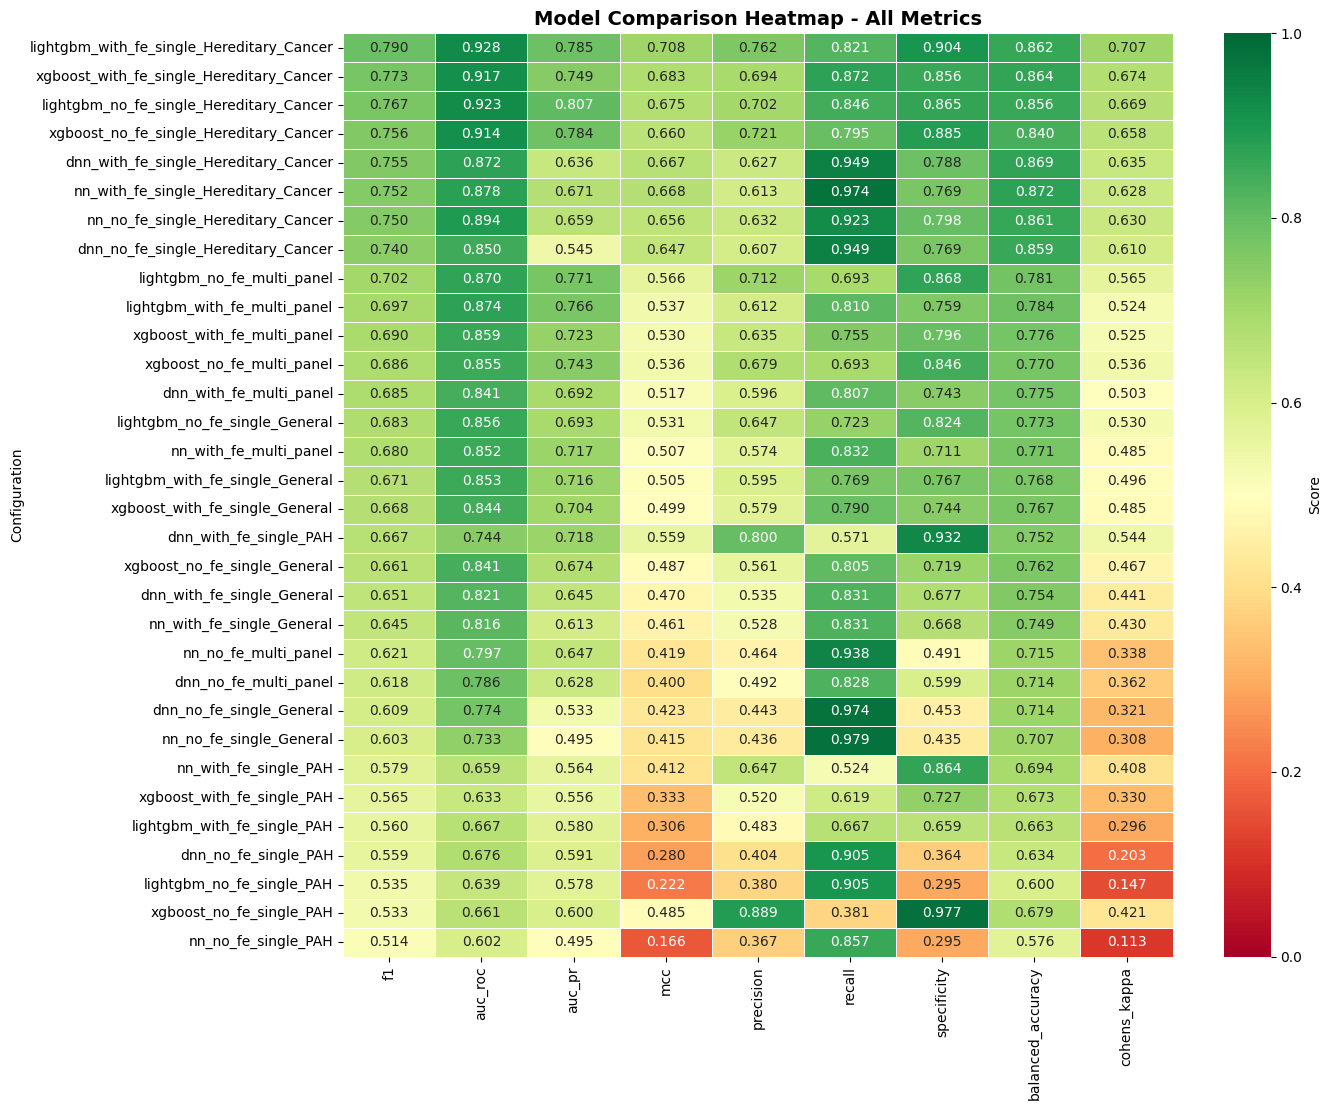

In [18]:
# =============================================================================
# BOLUM 7 - Cell 18: Model Comparison Heatmap
# =============================================================================
heatmap_data = sdf.set_index('config_id')[available_metrics].sort_values('f1', ascending=False)

fig, ax = plt.subplots(figsize=(14, max(8, len(heatmap_data) * 0.35)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5,
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Model Comparison Heatmap - All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Configuration')
plt.tight_layout()
plt.show()

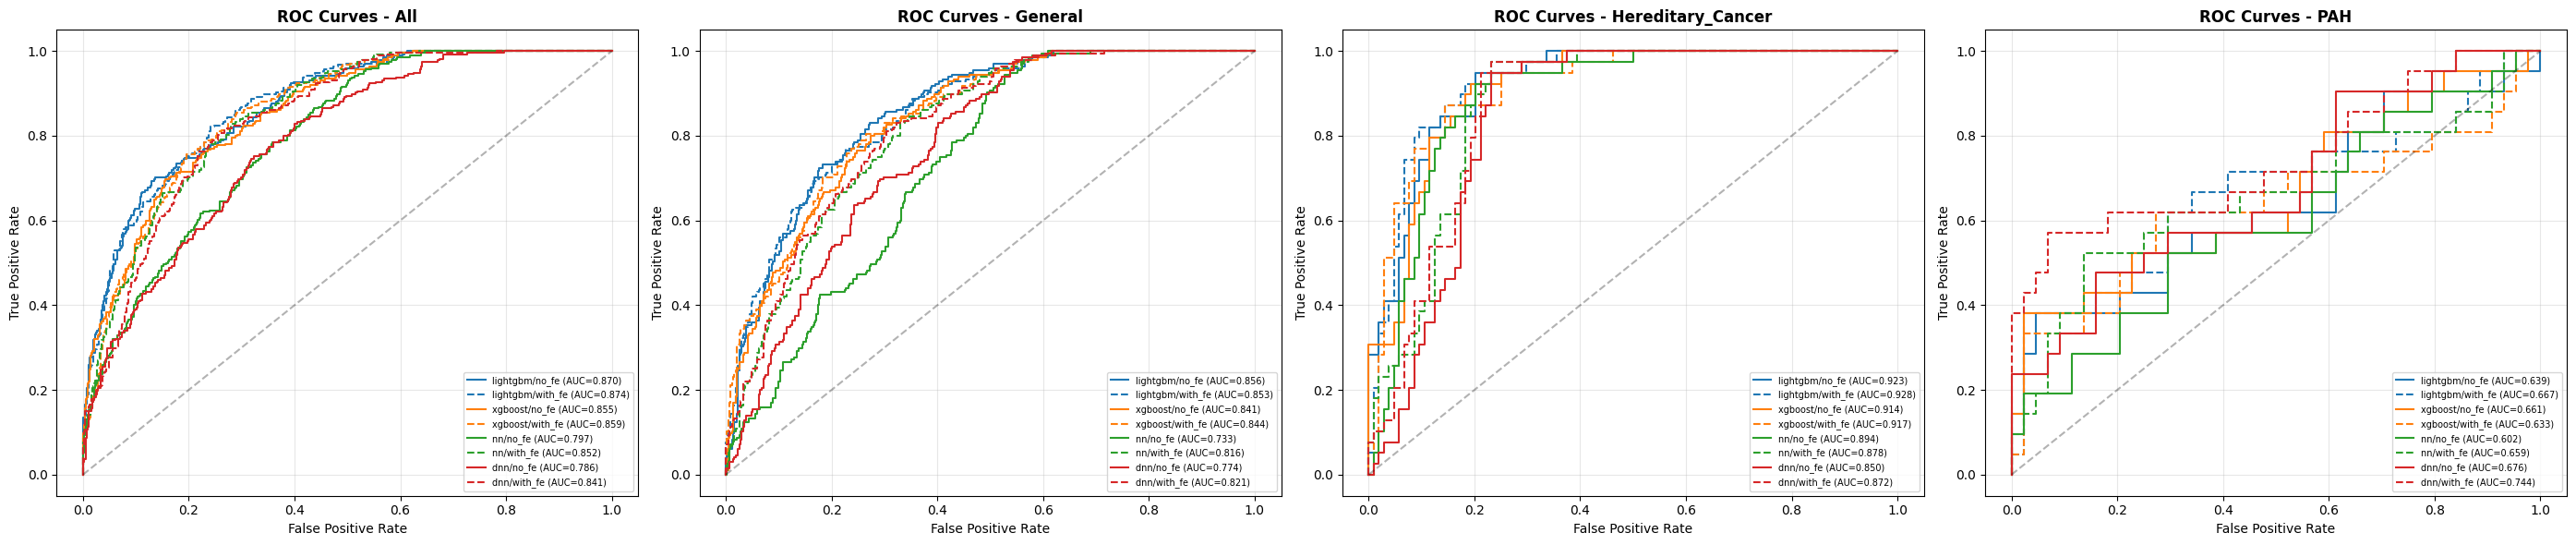

In [19]:
# =============================================================================
# BOLUM 7 - Cell 19: ROC Curves (Panel Bazinda)
# =============================================================================
panels_to_plot = list(sdf['panel'].unique())
n_panels = len(panels_to_plot)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))
if n_panels == 1:
    axes = [axes]

colors = {'lightgbm': 'tab:blue', 'xgboost': 'tab:orange', 'nn': 'tab:green', 'dnn': 'tab:red'}
linestyles = {'no_fe': '-', 'with_fe': '--'}

for ax, panel in zip(axes, panels_to_plot):
    panel_results = {cid: r for cid, r in RESULTS.items()
                     if 'error' not in r and r['panel'] == panel}
    
    for cid, res in panel_results.items():
        y_true = res['_y_test']
        y_prob = res['_y_pred_proba']
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = res['auc_roc']
        label = f"{res['model_type']}/{res['fe_state']} (AUC={auc_val:.3f})"
        ax.plot(fpr, tpr, color=colors.get(res['model_type'], 'gray'),
                linestyle=linestyles.get(res['fe_state'], '-'), linewidth=1.5, label=label)
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC Curves - {panel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

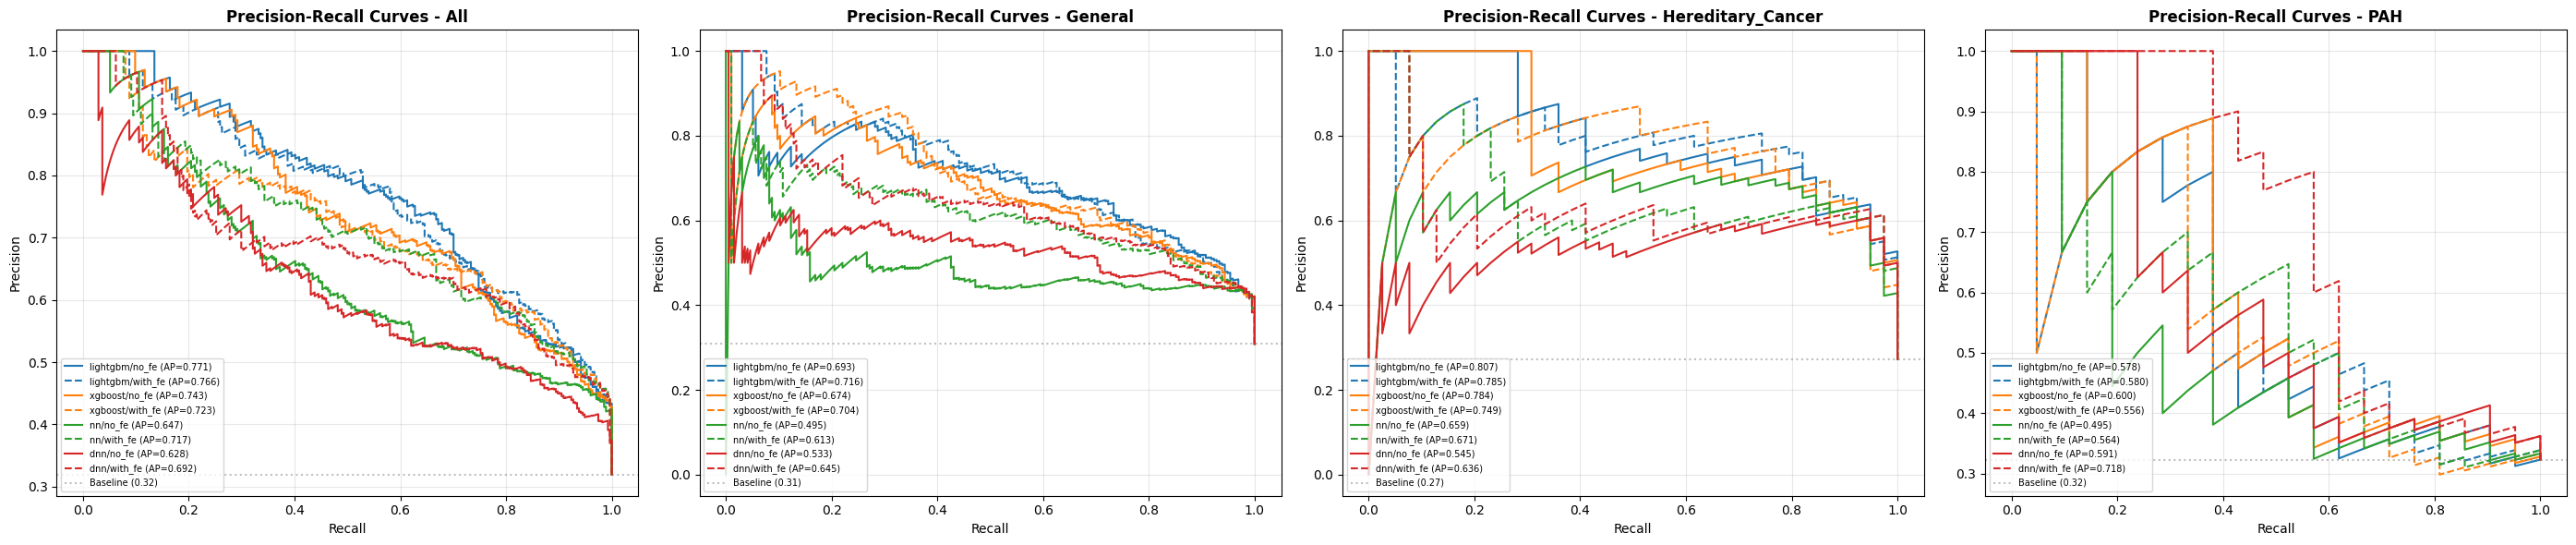

In [20]:
# =============================================================================
# BOLUM 7 - Cell 20: Precision-Recall Curves (Panel Bazinda)
# =============================================================================
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))
if n_panels == 1:
    axes = [axes]

for ax, panel in zip(axes, panels_to_plot):
    panel_results = {cid: r for cid, r in RESULTS.items()
                     if 'error' not in r and r['panel'] == panel}
    
    for cid, res in panel_results.items():
        y_true = res['_y_test']
        y_prob = res['_y_pred_proba']
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = res['auc_pr']
        label = f"{res['model_type']}/{res['fe_state']} (AP={ap:.3f})"
        ax.plot(rec, prec, color=colors.get(res['model_type'], 'gray'),
                linestyle=linestyles.get(res['fe_state'], '-'), linewidth=1.5, label=label)
    
    # Baseline = sinif prevalansi
    baseline = y_true.mean() if len(y_true) > 0 else 0.5
    ax.axhline(y=baseline, color='gray', linestyle=':', alpha=0.5, label=f'Baseline ({baseline:.2f})')
    ax.set_title(f'Precision-Recall Curves - {panel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

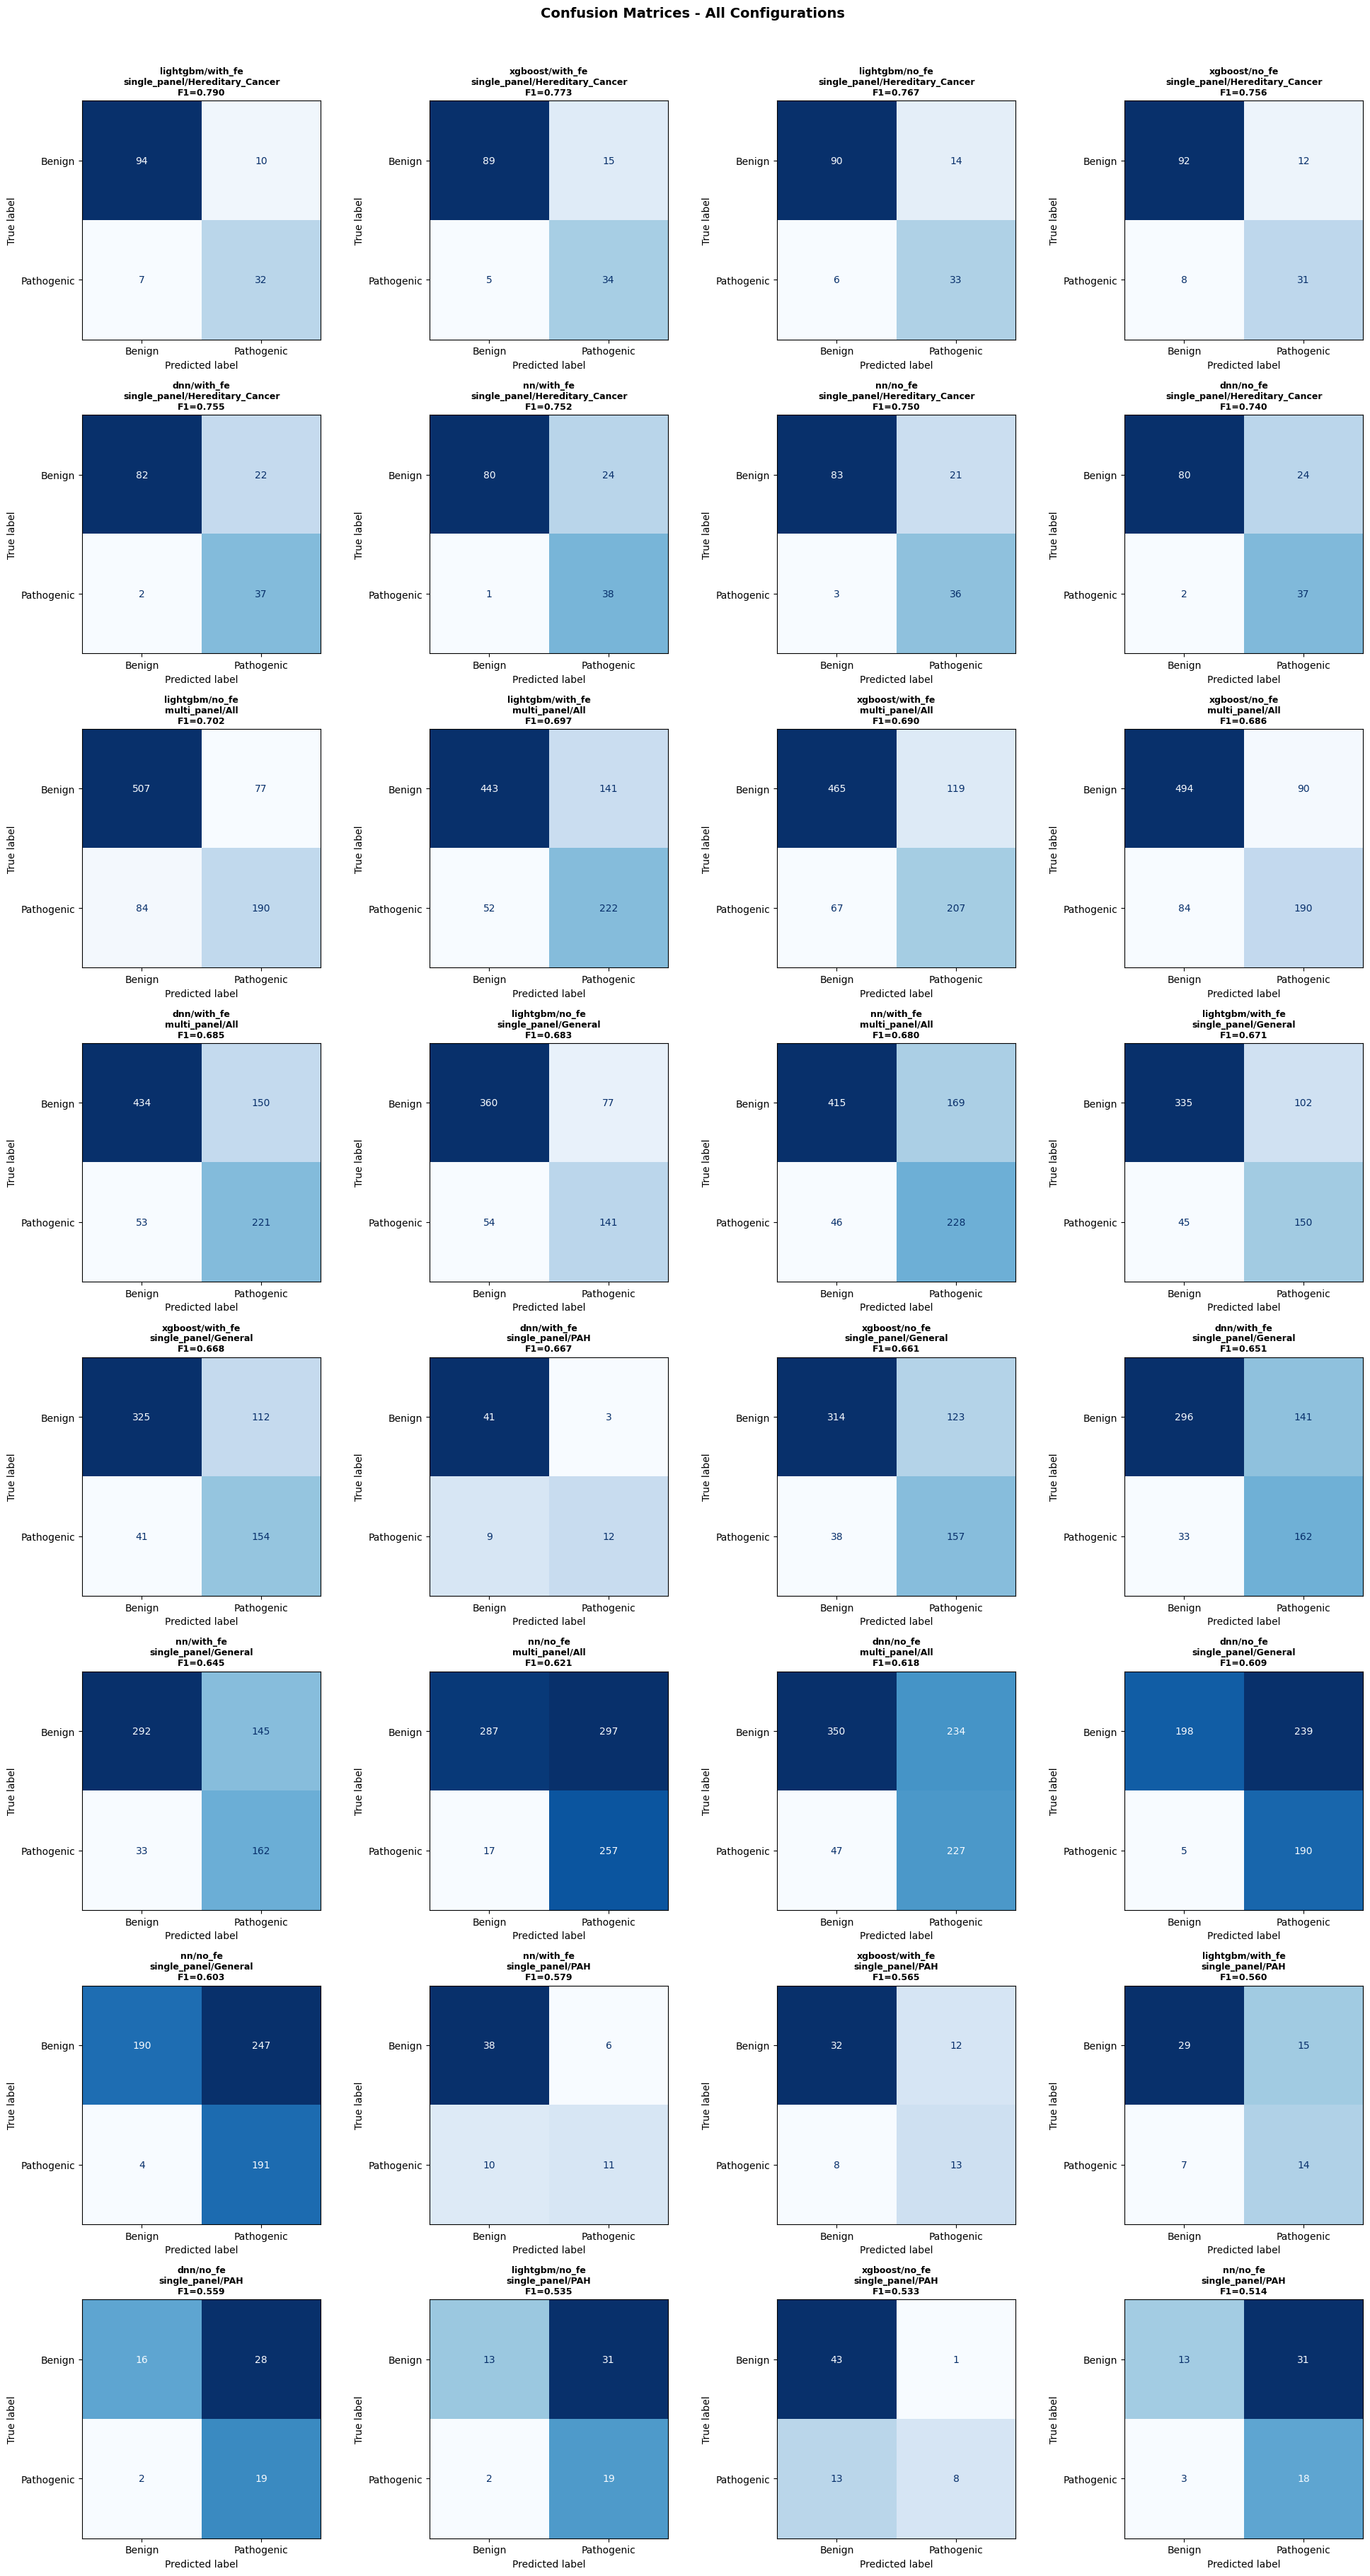

In [21]:
# =============================================================================
# BOLUM 7 - Cell 21: Confusion Matrix Grid
# =============================================================================
successful = {cid: r for cid, r in RESULTS.items() if 'error' not in r}
n_configs = len(successful)
n_cols = 4
n_rows = (n_configs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes_flat = axes.flatten() if n_rows > 1 else (axes if n_cols > 1 else [axes])

for idx, (cid, res) in enumerate(sorted(successful.items(), key=lambda x: -x[1]['f1'])):
    ax = axes_flat[idx]
    cm = confusion_matrix(res['_y_test'], res['_y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Pathogenic']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{res['model_type']}/{res['fe_state']}\n{res['mode']}/{res['panel']}\nF1={res['f1']:.3f}",
                 fontsize=9, fontweight='bold')

# Bos subplot'lari gizle
for idx in range(n_configs, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Confusion Matrices - All Configurations', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

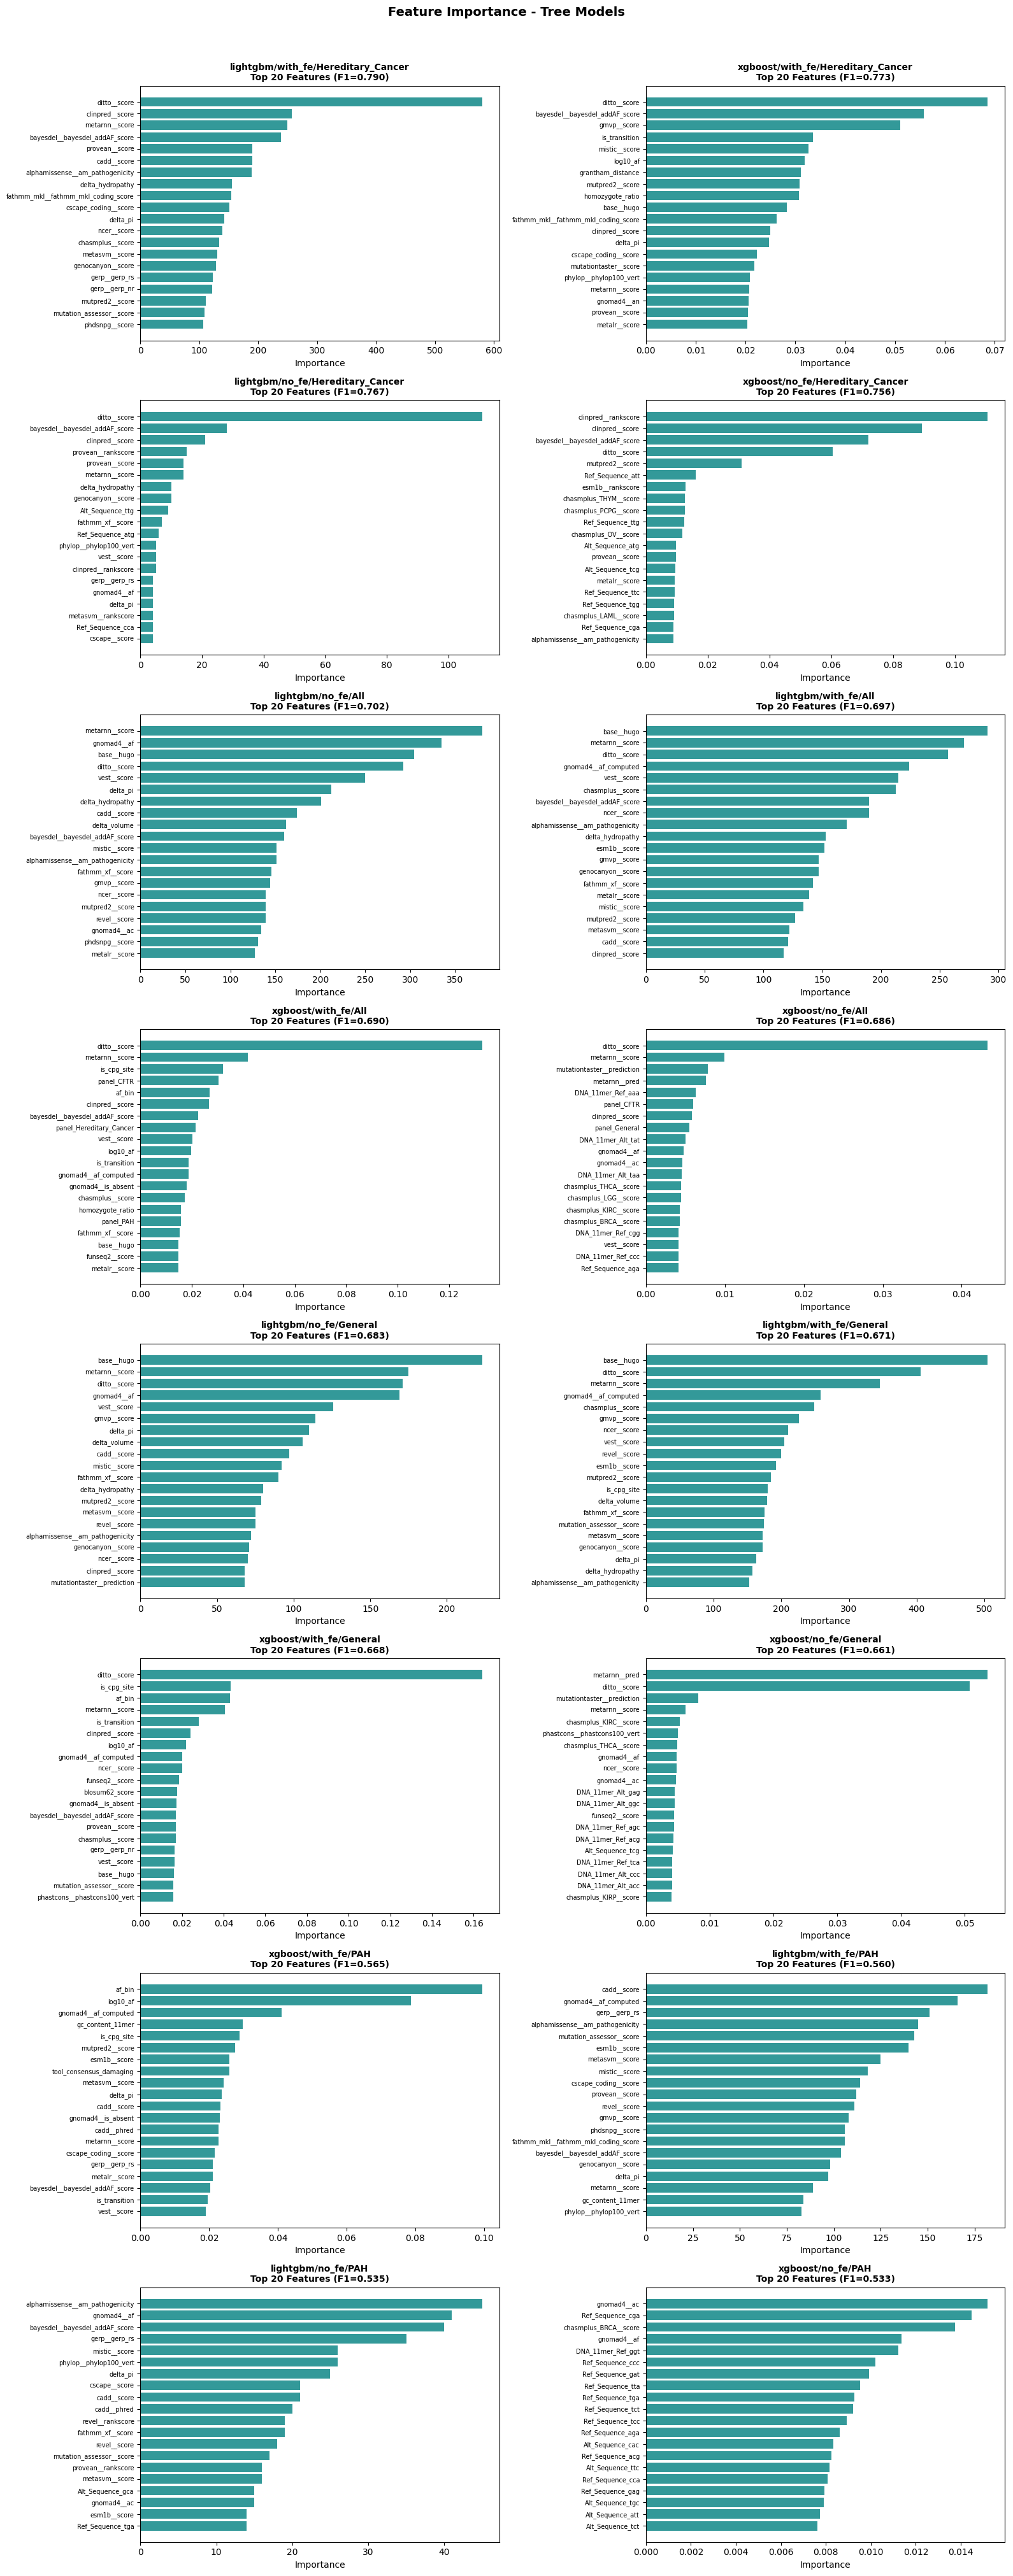

In [22]:
# =============================================================================
# BOLUM 7 - Cell 22: Feature Importance (Agac Modelleri)
# =============================================================================
tree_models = {cid: r for cid, r in RESULTS.items()
               if 'error' not in r and r['model_type'] in ('lightgbm', 'xgboost')
               and r['_feature_names'] is not None}

n_tree = len(tree_models)
if n_tree > 0:
    fig, axes = plt.subplots((n_tree + 1) // 2, 2, figsize=(16, 5 * ((n_tree + 1) // 2)))
    axes_flat = axes.flatten() if n_tree > 1 else [axes]
    
    for idx, (cid, res) in enumerate(sorted(tree_models.items(), key=lambda x: -x[1]['f1'])):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        model = res['_model']
        importance = model.feature_importances_
        fnames = res['_feature_names']
        
        top_n = min(20, len(importance))
        top_idx = np.argsort(importance)[-top_n:]
        
        ax.barh(range(top_n), importance[top_idx], color='teal', alpha=0.8)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([fnames[i] for i in top_idx], fontsize=7)
        ax.set_title(f'{res["model_type"]}/{res["fe_state"]}/{res["panel"]}\nTop {top_n} Features (F1={res["f1"]:.3f})',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Importance')
    
    for idx in range(n_tree, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle('Feature Importance - Tree Models', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Agac modeli bulunamadi.")

SHAP analizi: lightgbm_with_fe_single_Hereditary_Cancer (F1=0.7901)


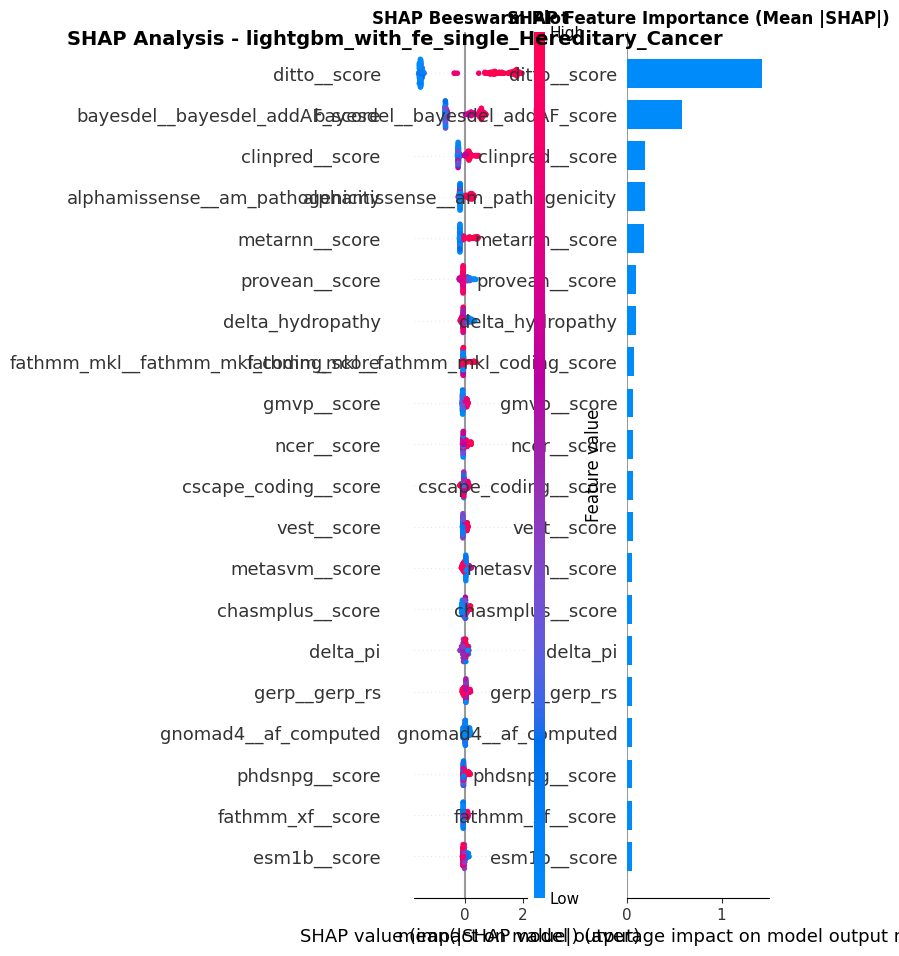

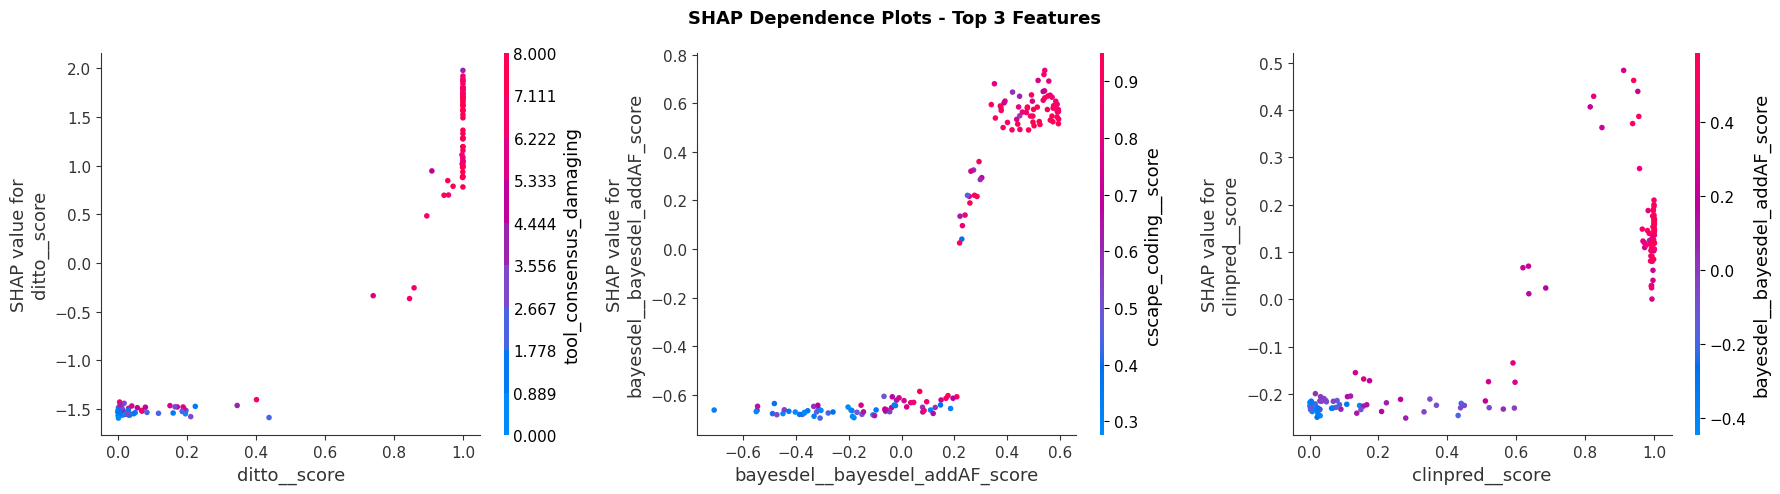

In [23]:
# =============================================================================
# BOLUM 7 - Cell 23: SHAP Values (En Iyi Agac Modeli)
# =============================================================================
# En iyi agac modelini bul
best_tree = None
best_tree_f1 = 0
for cid, res in RESULTS.items():
    if 'error' not in res and res['model_type'] in ('lightgbm', 'xgboost') and res['f1'] > best_tree_f1:
        best_tree = res
        best_tree_f1 = res['f1']

if best_tree is not None and best_tree['_feature_names'] is not None:
    print(f"SHAP analizi: {best_tree['config_id']} (F1={best_tree['f1']:.4f})")
    
    # SHAP icin test verisi hazirla
    df_src = df_with_fe if best_tree['fe_state'] == 'with_fe' else df_no_fe
    X_train_shap, X_test_shap, _, _, cat_feats = get_train_test_data(
        df_src, best_tree['mode'], best_tree['panel'] if best_tree['panel'] != 'All' else None)
    
    # XGBoost icin LabelEncode
    if best_tree['model_type'] == 'xgboost':
        X_train_shap, X_test_shap, _ = prepare_for_xgb(X_train_shap, X_test_shap, cat_feats)
    
    try:
        explainer = shap.TreeExplainer(best_tree['_model'])
        shap_values = explainer.shap_values(X_test_shap.head(200))  # Hiz icin 200 ornek
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Beeswarm plot
        plt.sca(axes[0])
        shap.summary_plot(shap_values, X_test_shap.head(200), plot_type="dot",
                         max_display=20, show=False)
        axes[0].set_title('SHAP Beeswarm Plot', fontsize=12, fontweight='bold')
        
        # Bar plot
        plt.sca(axes[1])
        shap.summary_plot(shap_values, X_test_shap.head(200), plot_type="bar",
                         max_display=20, show=False)
        axes[1].set_title('SHAP Feature Importance (Mean |SHAP|)', fontsize=12, fontweight='bold')
        
        plt.suptitle(f'SHAP Analysis - {best_tree["config_id"]}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Top 3 feature icin dependence plot
        top_features = pd.DataFrame({
            'feature': X_test_shap.columns,
            'importance': np.abs(shap_values).mean(axis=0)
        }).sort_values('importance', ascending=False).head(3)['feature'].tolist()
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for i, feat in enumerate(top_features):
            shap.dependence_plot(feat, shap_values, X_test_shap.head(200), ax=axes[i], show=False)
        plt.suptitle('SHAP Dependence Plots - Top 3 Features', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"SHAP hesaplama hatasi: {e}")
else:
    print("SHAP icin uygun agac modeli bulunamadi.")

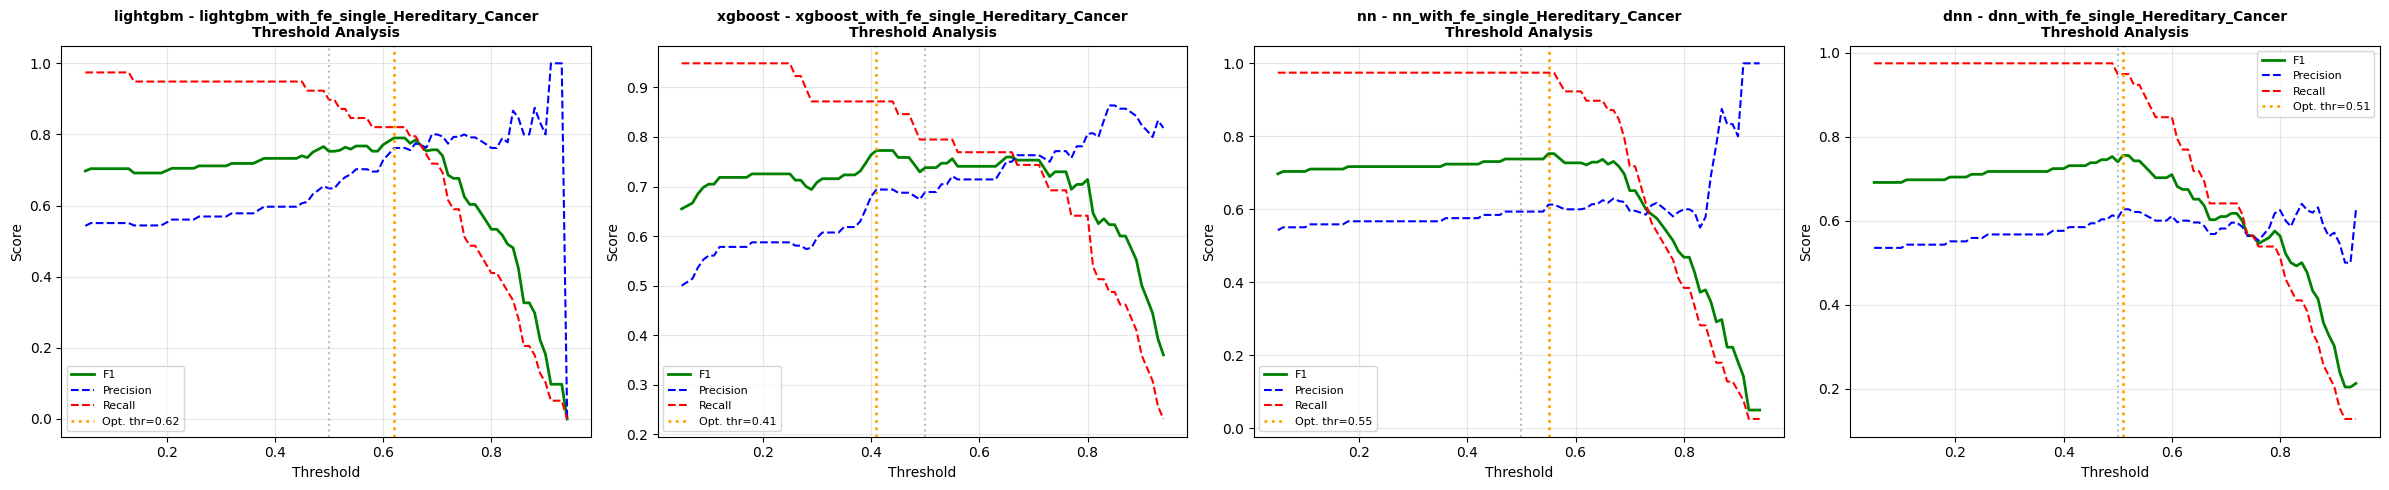

In [24]:
# =============================================================================
# BOLUM 7 - Cell 24: Threshold Analysis
# =============================================================================
# Her model tipi icin en iyi konfigurasyonu sec
best_per_type = {}
for cid, res in successful.items():
    mt = res['model_type']
    if mt not in best_per_type or res['f1'] > best_per_type[mt]['f1']:
        best_per_type[mt] = res

fig, axes = plt.subplots(1, len(best_per_type), figsize=(6 * len(best_per_type), 5))
if len(best_per_type) == 1:
    axes = [axes]

for ax, (mt, res) in zip(axes, best_per_type.items()):
    thrs = np.arange(0.05, 0.95, 0.01)
    y_true = res['_y_test']
    y_prob = res['_y_pred_proba']
    
    f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thrs]
    precs = [precision_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thrs]
    recs = [recall_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thrs]
    
    ax.plot(thrs, f1s, 'g-', linewidth=2, label='F1')
    ax.plot(thrs, precs, 'b--', linewidth=1.5, label='Precision')
    ax.plot(thrs, recs, 'r--', linewidth=1.5, label='Recall')
    ax.axvline(res['best_threshold'], color='orange', linestyle=':', linewidth=2,
               label=f'Opt. thr={res["best_threshold"]:.2f}')
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'{mt} - {res["config_id"]}\nThreshold Analysis', fontsize=10, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

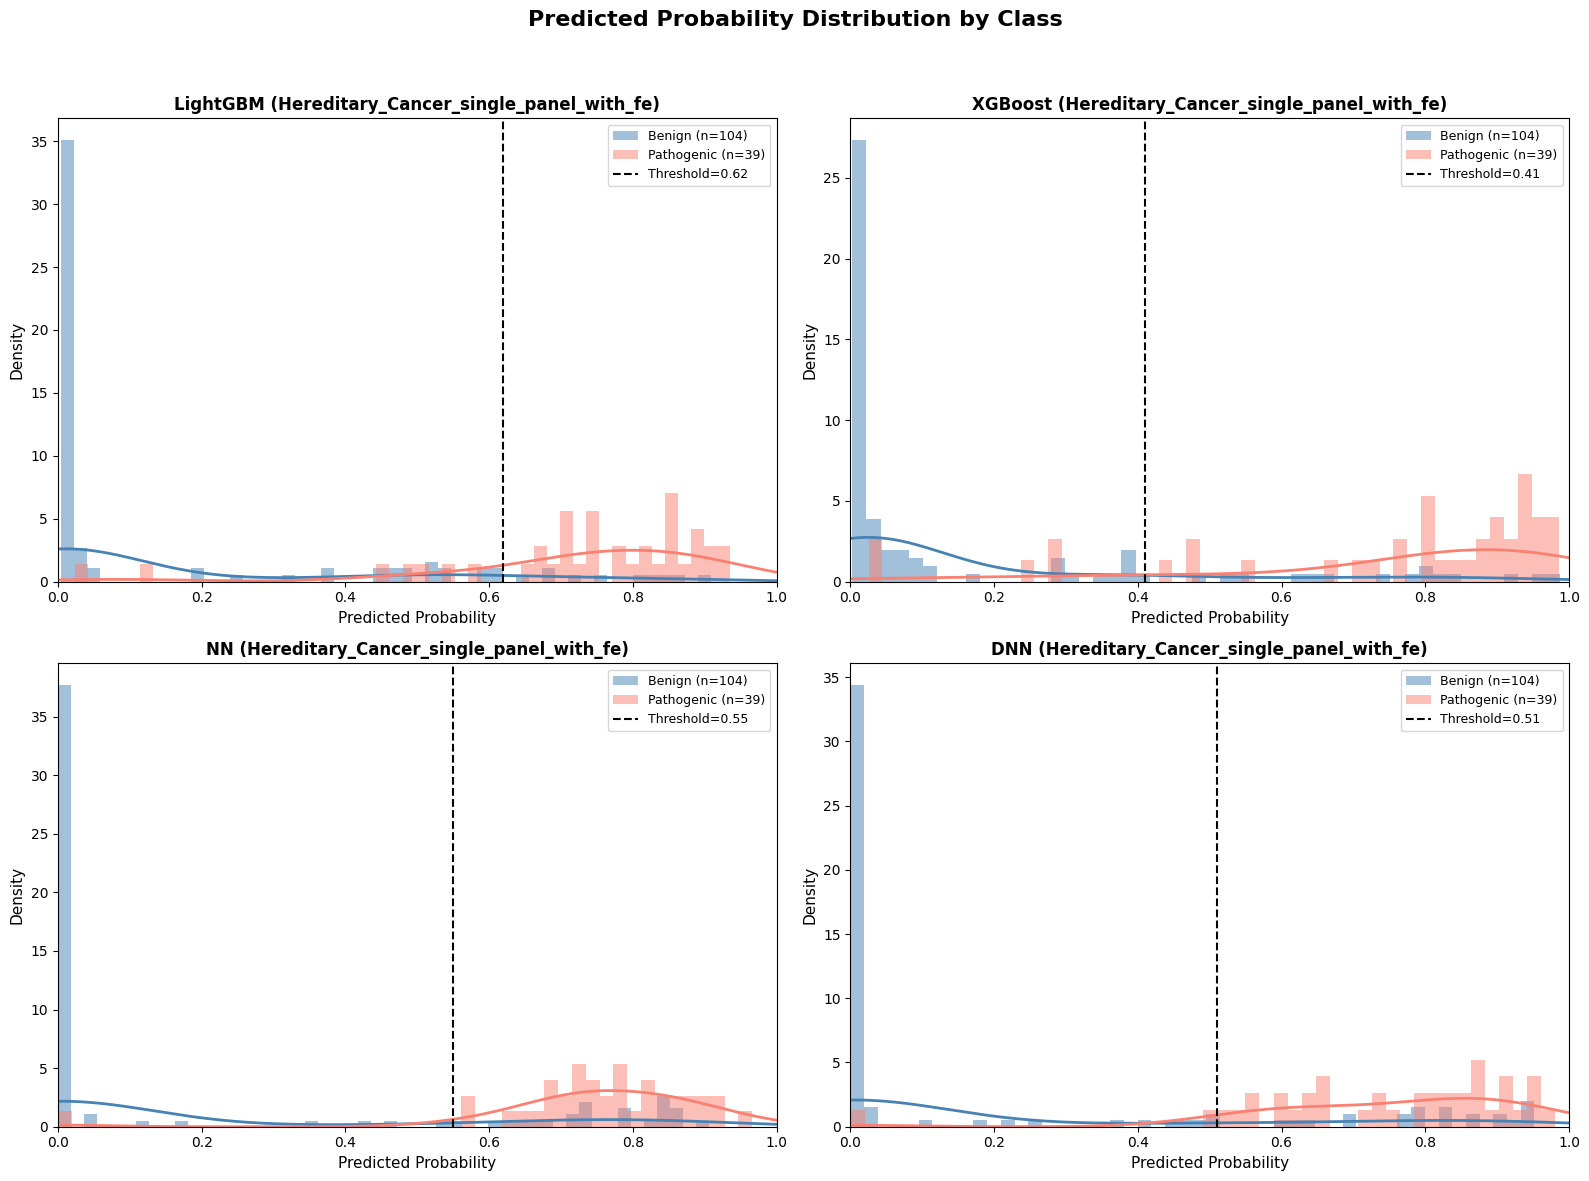

Score Distribution grafigi kaydedildi: score_distribution.png


In [25]:
# =============================================================================
# BOLUM 7 - Cell 25: Score Distribution - Tahmin olasilik dagilimi (sinif bazinda)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Predicted Probability Distribution by Class', fontsize=16, fontweight='bold')

MODEL_TYPES_DISPLAY = ['lightgbm', 'xgboost', 'nn', 'dnn']
MODEL_LABELS = {'lightgbm': 'LightGBM', 'xgboost': 'XGBoost', 'nn': 'NN', 'dnn': 'DNN'}

for idx, mt in enumerate(MODEL_TYPES_DISPLAY):
    ax = axes[idx // 2][idx % 2]
    
    # Bu model tipine ait basarili sonuclari filtrele
    mt_results = {cid: r for cid, r in RESULTS.items()
                  if 'error' not in r and r['model_type'] == mt}
    
    if not mt_results:
        ax.text(0.5, 0.5, f'{MODEL_LABELS[mt]}\nNo results', ha='center', va='center', fontsize=14)
        ax.set_title(MODEL_LABELS[mt])
        continue
    
    # En iyi F1'e sahip konfigurasyonu sec
    best_cid = max(mt_results, key=lambda c: mt_results[c]['f1'])
    best_res = mt_results[best_cid]
    y_true = best_res['_y_test']
    y_prob = best_res['_y_pred_proba']
    
    # Sinif bazinda olasilik dagilimi
    benign_probs = y_prob[y_true == 0]
    pathogenic_probs = y_prob[y_true == 1]
    
    # Histogram + KDE
    ax.hist(benign_probs, bins=50, alpha=0.5, color='steelblue', label=f'Benign (n={len(benign_probs)})', density=True)
    ax.hist(pathogenic_probs, bins=50, alpha=0.5, color='salmon', label=f'Pathogenic (n={len(pathogenic_probs)})', density=True)
    
    # KDE overlay
    from scipy.stats import gaussian_kde
    if len(benign_probs) > 1:
        kde_b = gaussian_kde(benign_probs)
        x_range = np.linspace(0, 1, 200)
        ax.plot(x_range, kde_b(x_range), color='steelblue', linewidth=2)
    if len(pathogenic_probs) > 1:
        kde_p = gaussian_kde(pathogenic_probs)
        x_range = np.linspace(0, 1, 200)
        ax.plot(x_range, kde_p(x_range), color='salmon', linewidth=2)
    
    # Threshold cizgisi
    best_thresh = best_res['best_threshold']
    ax.axvline(x=best_thresh, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={best_thresh:.2f}')
    
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    config_label = f"{best_res['panel']}_{best_res['mode']}_{best_res['fe_state']}"
    ax.set_title(f'{MODEL_LABELS[mt]} ({config_label})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Score Distribution grafigi kaydedildi: score_distribution.png")

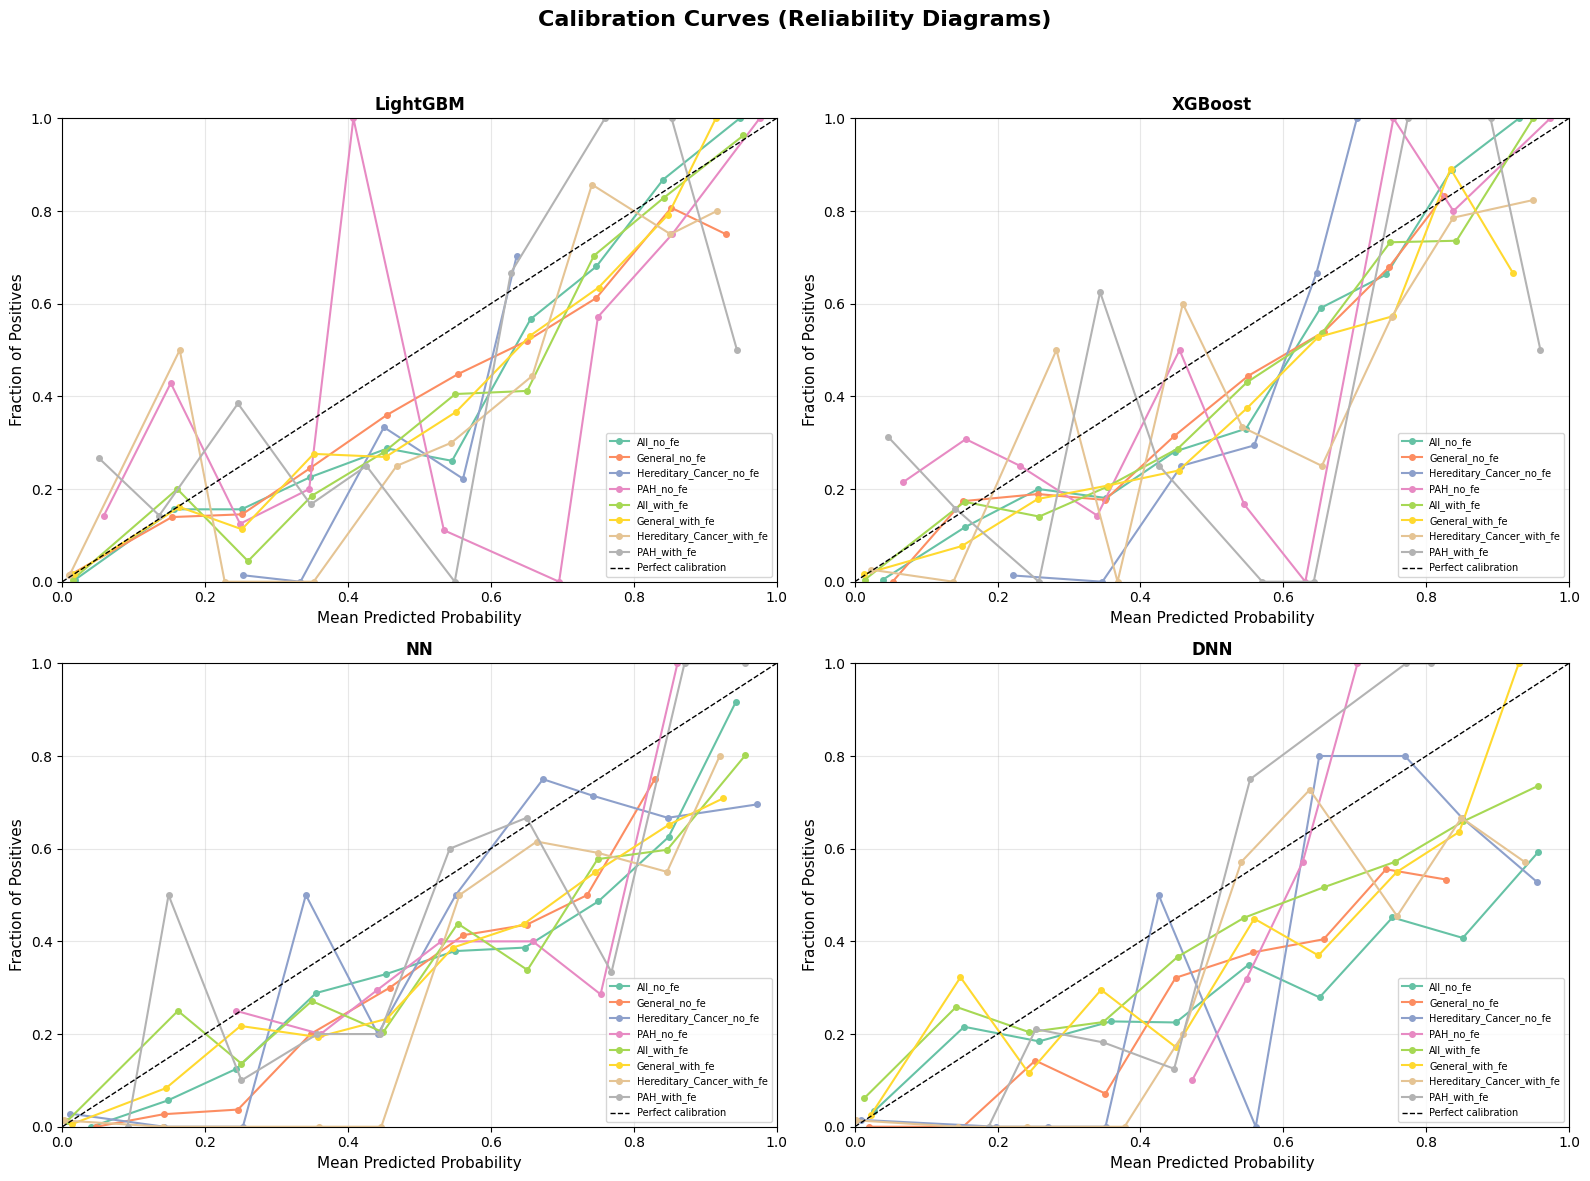

Calibration Curves grafigi kaydedildi: calibration_curves.png


In [26]:
# =============================================================================
# BOLUM 7 - Cell 26: Calibration Curves - Model kalibrasyon egrileri
# =============================================================================
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Calibration Curves (Reliability Diagrams)', fontsize=16, fontweight='bold')

for idx, mt in enumerate(MODEL_TYPES_DISPLAY):
    ax = axes[idx // 2][idx % 2]
    
    # Bu model tipine ait basarili sonuclar
    mt_results = {cid: r for cid, r in RESULTS.items()
                  if 'error' not in r and r['model_type'] == mt}
    
    if not mt_results:
        ax.text(0.5, 0.5, f'{MODEL_LABELS[mt]}\nNo results', ha='center', va='center', fontsize=14)
        ax.set_title(MODEL_LABELS[mt])
        continue
    
    # Her konfigurasyon icin kalibrasyon egrisi ciz
    colors = plt.cm.Set2(np.linspace(0, 1, len(mt_results)))
    for i, (cid, res) in enumerate(mt_results.items()):
        y_true = res['_y_test']
        y_prob = res['_y_pred_proba']
        config_label = f"{res['panel']}_{res['fe_state']}"
        
        try:
            fraction_of_positives, mean_predicted_value = calibration_curve(
                y_true, y_prob, n_bins=10, strategy='uniform'
            )
            ax.plot(mean_predicted_value, fraction_of_positives, 
                   marker='o', markersize=4, color=colors[i], label=config_label, linewidth=1.5)
        except Exception:
            continue
    
    # Mukemmel kalibrasyon cizgisi
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax.set_ylabel('Fraction of Positives', fontsize=11)
    ax.set_title(MODEL_LABELS[mt], fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Calibration Curves grafigi kaydedildi: calibration_curves.png")

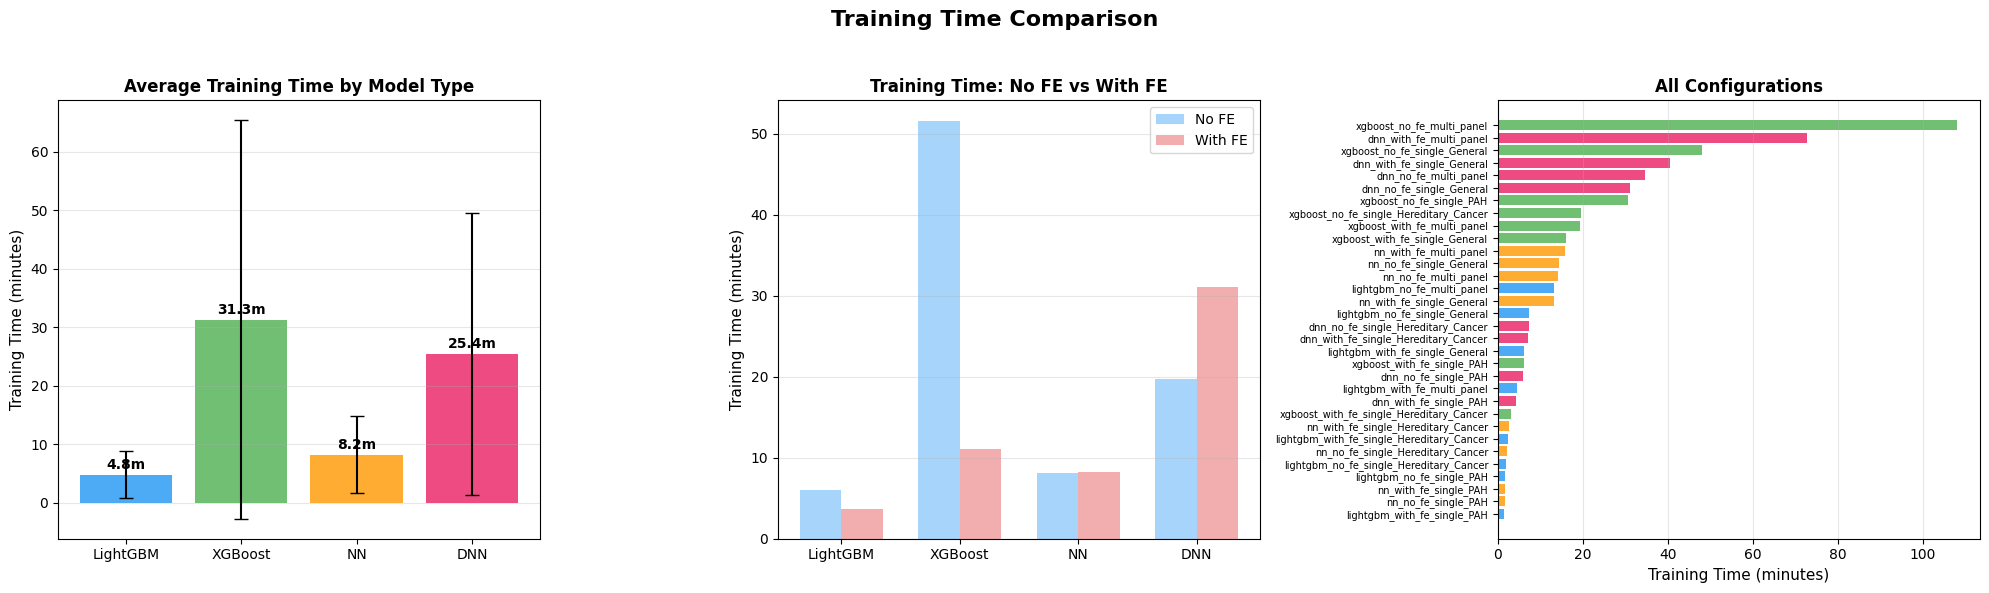


Toplam egitim suresi: 558.3 dakika (9.3 saat)
Ortalama konfigurasyon suresi: 17.4 dakika


In [27]:
# =============================================================================
# BOLUM 7 - Cell 27: Training Time Comparison - Egitim suresi karsilastirmasi
# =============================================================================

# Basarili sonuclardan sure bilgilerini al
successful_results = {cid: r for cid, r in RESULTS.items() if 'error' not in r}

time_data = []
for cid, r in successful_results.items():
    if 'time_seconds' in r:
        time_data.append({
            'Config': cid,
            'Model': r['model_type'],
            'FE': r['fe_state'],
            'Mode': r['mode'],
            'Panel': r['panel'],
            'Time (min)': r['time_seconds'] / 60.0
        })

if time_data:
    df_time = pd.DataFrame(time_data)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Training Time Comparison', fontsize=16, fontweight='bold')
    
    # 1) Model tipine gore ortalama sure
    ax1 = axes[0]
    model_times = df_time.groupby('Model')['Time (min)'].agg(['mean', 'std']).reindex(MODEL_TYPES_DISPLAY)
    bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    bars = ax1.bar(model_times.index.map(MODEL_LABELS), model_times['mean'], 
                   yerr=model_times['std'].fillna(0), capsize=5,
                   color=bar_colors, alpha=0.8)
    ax1.set_ylabel('Training Time (minutes)', fontsize=11)
    ax1.set_title('Average Training Time by Model Type', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, model_times['mean']):
        if not np.isnan(val):
            ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    f'{val:.1f}m', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2) FE durumuna gore sure
    ax2 = axes[1]
    fe_model_times = df_time.groupby(['Model', 'FE'])['Time (min)'].mean().unstack(fill_value=0)
    fe_model_times = fe_model_times.reindex(MODEL_TYPES_DISPLAY)
    x = np.arange(len(fe_model_times.index))
    width = 0.35
    if 'no_fe' in fe_model_times.columns:
        ax2.bar(x - width/2, fe_model_times['no_fe'], width, label='No FE', color='#90CAF9', alpha=0.8)
    if 'with_fe' in fe_model_times.columns:
        ax2.bar(x + width/2, fe_model_times['with_fe'], width, label='With FE', color='#EF9A9A', alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels([MODEL_LABELS[m] for m in fe_model_times.index])
    ax2.set_ylabel('Training Time (minutes)', fontsize=11)
    ax2.set_title('Training Time: No FE vs With FE', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 3) Tum konfigurasyonlar - yatay bar chart
    ax3 = axes[2]
    df_time_sorted = df_time.sort_values('Time (min)', ascending=True)
    colors_map = {'lightgbm': '#2196F3', 'xgboost': '#4CAF50', 'nn': '#FF9800', 'dnn': '#E91E63'}
    bar_colors = [colors_map.get(m, 'gray') for m in df_time_sorted['Model']]
    ax3.barh(range(len(df_time_sorted)), df_time_sorted['Time (min)'], color=bar_colors, alpha=0.8)
    ax3.set_yticks(range(len(df_time_sorted)))
    ax3.set_yticklabels(df_time_sorted['Config'], fontsize=7)
    ax3.set_xlabel('Training Time (minutes)', fontsize=11)
    ax3.set_title('All Configurations', fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('training_time_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    total_time = df_time['Time (min)'].sum()
    print(f"\nToplam egitim suresi: {total_time:.1f} dakika ({total_time/60:.1f} saat)")
    print(f"Ortalama konfigurasyon suresi: {df_time['Time (min)'].mean():.1f} dakika")
else:
    print("Egitim suresi bilgisi bulunamadi.")

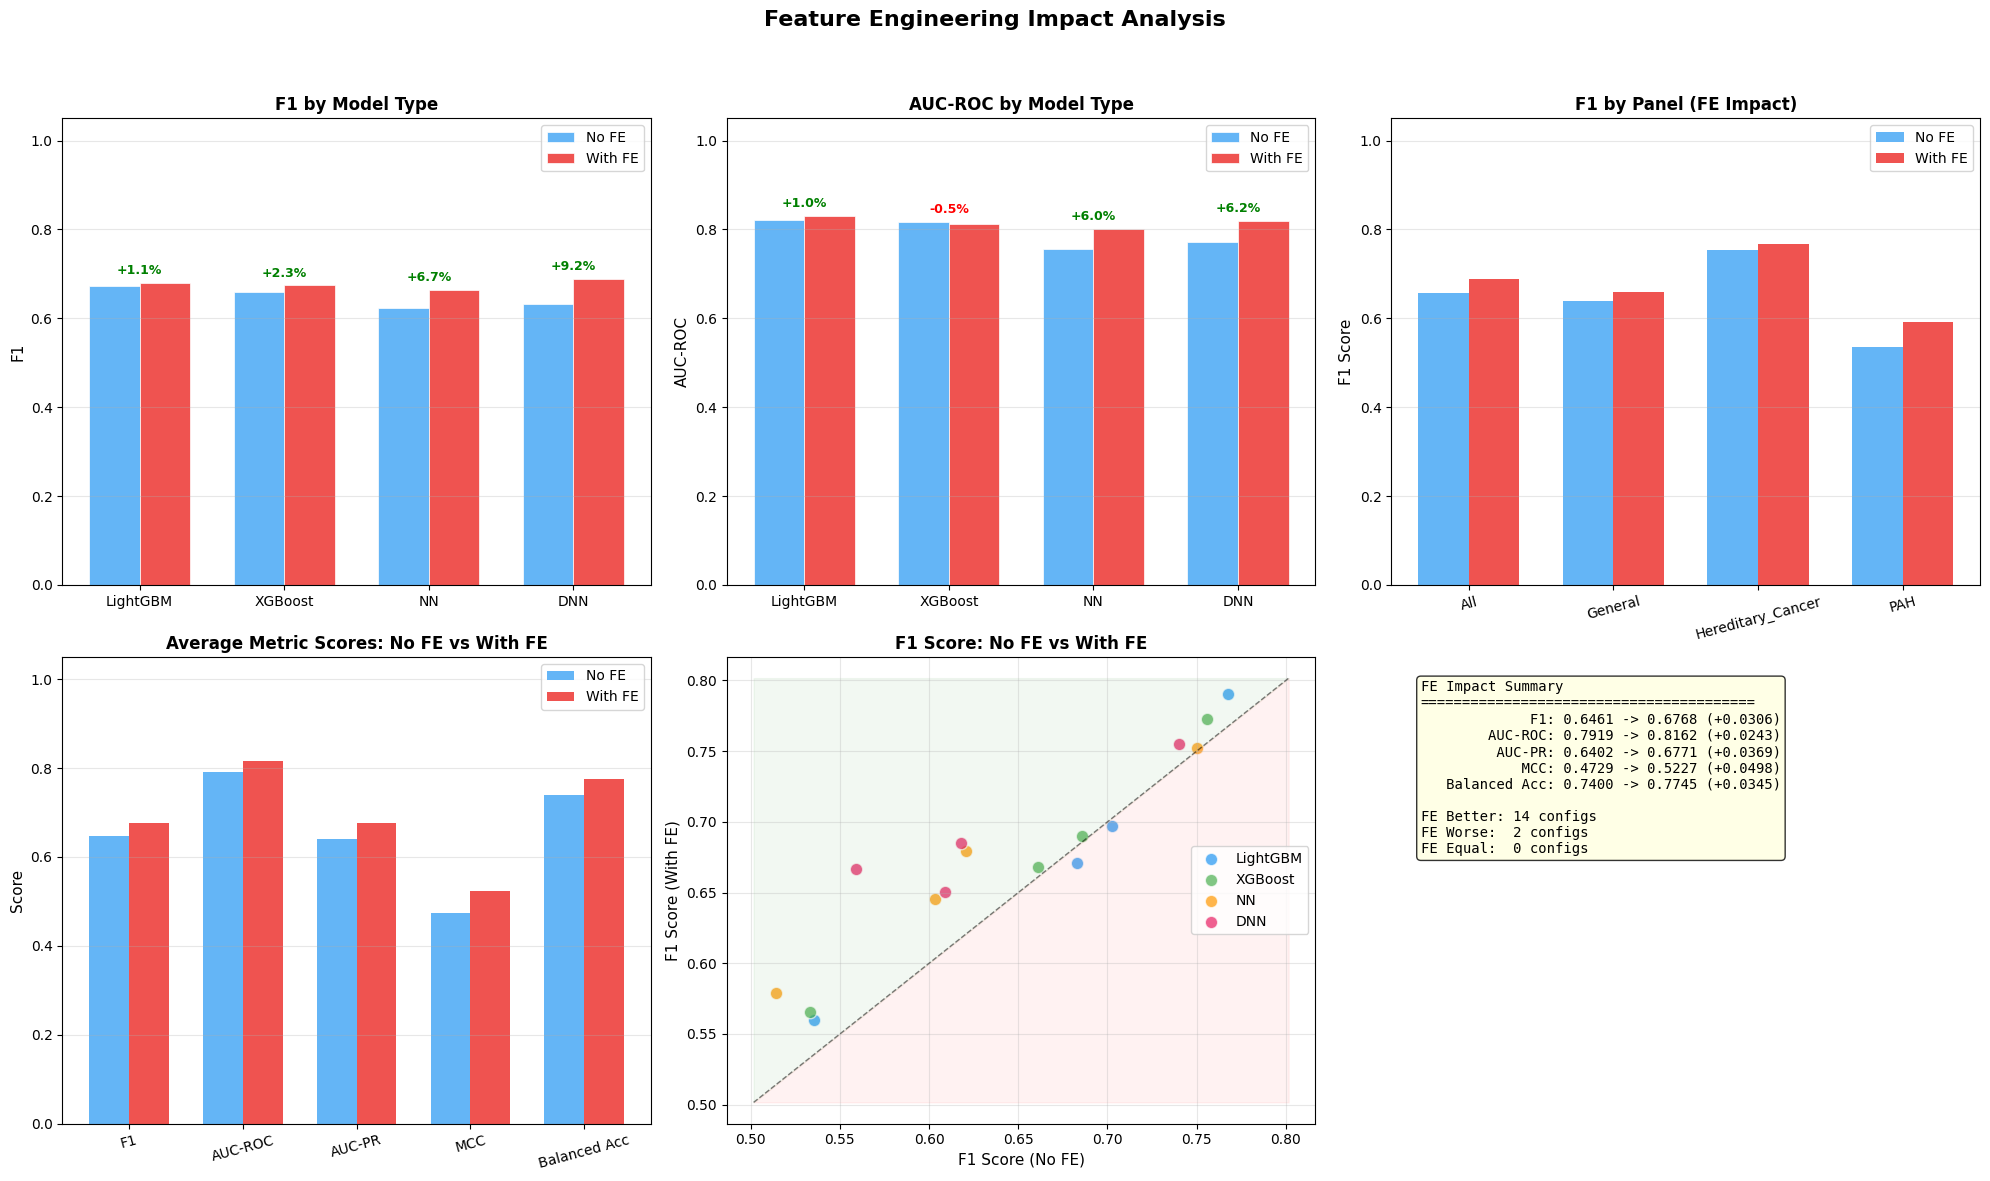

FE Impact Analysis grafigi kaydedildi: fe_impact_analysis.png


In [28]:
# =============================================================================
# BOLUM 7 - Cell 28: FE Impact - Feature Engineering etkisi karsilastirmasi
# =============================================================================

metrics_to_compare = ['f1', 'auc_roc', 'auc_pr', 'mcc', 'balanced_accuracy']
metric_labels = {'f1': 'F1', 'auc_roc': 'AUC-ROC', 'auc_pr': 'AUC-PR', 
                 'mcc': 'MCC', 'balanced_accuracy': 'Balanced Acc'}

# Basarili sonuclardan FE karsilastirma verisi hazirla
fe_impact_data = []
for cid, r in RESULTS.items():
    if 'error' in r:
        continue
    for metric in metrics_to_compare:
        if metric in r:
            fe_impact_data.append({
                'Model': r['model_type'],
                'Panel': r['panel'],
                'Mode': r['mode'],
                'FE': r['fe_state'],
                'Metric': metric,
                'Value': r[metric]
            })

if fe_impact_data:
    df_fe = pd.DataFrame(fe_impact_data)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Feature Engineering Impact Analysis', fontsize=16, fontweight='bold')
    
    width = 0.35
    
    # 1) Model bazinda FE etkisi (F1 ve AUC-ROC)
    for m_idx, metric in enumerate(['f1', 'auc_roc']):
        ax = axes[0][m_idx]
        pivot = df_fe[df_fe['Metric'] == metric].groupby(['Model', 'FE'])['Value'].mean().unstack(fill_value=0)
        pivot = pivot.reindex(MODEL_TYPES_DISPLAY)
        x = np.arange(len(pivot.index))
        
        bars1 = ax.bar(x - width/2, pivot.get('no_fe', 0), width, label='No FE', 
                       color='#64B5F6', edgecolor='white', linewidth=0.5)
        bars2 = ax.bar(x + width/2, pivot.get('with_fe', 0), width, label='With FE', 
                       color='#EF5350', edgecolor='white', linewidth=0.5)
        
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_LABELS[m] for m in pivot.index])
        ax.set_ylabel(metric_labels[metric], fontsize=11)
        ax.set_title(f'{metric_labels[metric]} by Model Type', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1.05)
        
        # Fark yuzdesini goster
        for i, model in enumerate(pivot.index):
            no_fe_val = pivot.get('no_fe', pd.Series()).get(model, 0)
            with_fe_val = pivot.get('with_fe', pd.Series()).get(model, 0)
            if no_fe_val > 0:
                diff_pct = ((with_fe_val - no_fe_val) / no_fe_val) * 100
                color = 'green' if diff_pct >= 0 else 'red'
                ax.text(i, max(no_fe_val, with_fe_val) + 0.02, 
                       f'{diff_pct:+.1f}%', ha='center', fontsize=9, color=color, fontweight='bold')
    
    # 2) Panel bazinda FE etkisi (F1)
    ax = axes[0][2]
    pivot_panel = df_fe[df_fe['Metric'] == 'f1'].groupby(['Panel', 'FE'])['Value'].mean().unstack(fill_value=0)
    x = np.arange(len(pivot_panel.index))
    
    ax.bar(x - width/2, pivot_panel.get('no_fe', 0), width, label='No FE', color='#64B5F6')
    ax.bar(x + width/2, pivot_panel.get('with_fe', 0), width, label='With FE', color='#EF5350')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_panel.index, rotation=15)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title('F1 by Panel (FE Impact)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    # 3) Her metrik icin ortalama FE etkisi
    ax = axes[1][0]
    fe_summary = df_fe.groupby(['Metric', 'FE'])['Value'].mean().unstack(fill_value=0)
    fe_summary = fe_summary.reindex(metrics_to_compare)
    x = np.arange(len(fe_summary.index))
    
    ax.bar(x - width/2, fe_summary.get('no_fe', 0), width, label='No FE', color='#64B5F6')
    ax.bar(x + width/2, fe_summary.get('with_fe', 0), width, label='With FE', color='#EF5350')
    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels[m] for m in fe_summary.index], rotation=15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Average Metric Scores: No FE vs With FE', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    # 4) FE etkisi - scatter plot (no-FE x, with-FE y)
    ax = axes[1][1]
    scatter_data = df_fe[df_fe['Metric'] == 'f1'].pivot_table(
        index=['Model', 'Panel', 'Mode'], columns='FE', values='Value'
    ).dropna()
    
    if 'no_fe' in scatter_data.columns and 'with_fe' in scatter_data.columns:
        colors_map = {'lightgbm': '#2196F3', 'xgboost': '#4CAF50', 'nn': '#FF9800', 'dnn': '#E91E63'}
        for mt in MODEL_TYPES_DISPLAY:
            mask = scatter_data.index.get_level_values('Model') == mt
            if mask.any():
                ax.scatter(scatter_data.loc[mask, 'no_fe'], scatter_data.loc[mask, 'with_fe'],
                          label=MODEL_LABELS[mt], color=colors_map[mt], s=80, alpha=0.7, edgecolors='white')
        
        lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
        ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
        ax.fill_between(lims, lims, [lims[1]]*2, alpha=0.05, color='green')
        ax.fill_between(lims, [lims[0]]*2, lims, alpha=0.05, color='red')
        
    ax.set_xlabel('F1 Score (No FE)', fontsize=11)
    ax.set_ylabel('F1 Score (With FE)', fontsize=11)
    ax.set_title('F1 Score: No FE vs With FE', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5) FE etkisi ozet istatistikleri
    ax = axes[1][2]
    ax.axis('off')
    
    summary_lines = []
    for metric in metrics_to_compare:
        m_data = df_fe[df_fe['Metric'] == metric]
        no_fe_avg = m_data[m_data['FE'] == 'no_fe']['Value'].mean()
        with_fe_avg = m_data[m_data['FE'] == 'with_fe']['Value'].mean()
        diff = with_fe_avg - no_fe_avg
        summary_lines.append(f"{metric_labels[metric]:>15s}: {no_fe_avg:.4f} -> {with_fe_avg:.4f} ({diff:+.4f})")
    
    if 'no_fe' in scatter_data.columns and 'with_fe' in scatter_data.columns:
        fe_better = (scatter_data['with_fe'] > scatter_data['no_fe']).sum()
        fe_worse = (scatter_data['with_fe'] < scatter_data['no_fe']).sum()
        fe_equal = (scatter_data['with_fe'] == scatter_data['no_fe']).sum()
        summary_lines.append(f"\nFE Better: {fe_better} configs")
        summary_lines.append(f"FE Worse:  {fe_worse} configs")
        summary_lines.append(f"FE Equal:  {fe_equal} configs")
    
    summary_text = "FE Impact Summary\n" + "="*40 + "\n" + "\n".join(summary_lines)
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('fe_impact_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("FE Impact Analysis grafigi kaydedildi: fe_impact_analysis.png")
else:
    print("FE karsilastirmasi icin yeterli veri bulunamadi.")

# 8. Final Report & Model Export

## Automated Analysis Report
This section generates a comprehensive report analyzing all 32 configurations, identifying the best-performing models, evaluating the impact of feature engineering, and providing actionable recommendations for deployment.

In [29]:
# =============================================================================
# BOLUM 8 - Cell 30: Otomatik Rapor Olusturma
# =============================================================================

# Basarili sonuclar
successful_res = {cid: r for cid, r in RESULTS.items() if 'error' not in r}
failed_res = {cid: r for cid, r in RESULTS.items() if 'error' in r}

print("=" * 80)
print("  COMPREHENSIVE MODEL COMPARISON REPORT")
print("  Genetic Variant Pathogenicity Prediction")
print("=" * 80)

# --- 1. GENEL BAKIS ---
print("\n" + "=" * 80)
print("  1. EXPERIMENT OVERVIEW")
print("=" * 80)

print(f"\n  Total configurations attempted: {len(RESULTS)}")
print(f"  Successful: {len(successful_res)}")
print(f"  Failed/Skipped: {len(failed_res)}")

if time_data:
    total_min = sum(t['Time (min)'] for t in time_data)
    print(f"  Total training time: {total_min:.1f} minutes ({total_min/60:.1f} hours)")

# --- 2. EN IYI MODEL ---
print("\n" + "=" * 80)
print("  2. BEST MODEL (Overall)")
print("=" * 80)

if successful_res:
    best_cid = max(successful_res, key=lambda c: successful_res[c]['f1'])
    best_overall = successful_res[best_cid]
    print(f"\n  Config:   {best_cid}")
    print(f"  Model:    {best_overall['model_type']}")
    print(f"  Panel:    {best_overall['panel']}")
    print(f"  Mode:     {best_overall['mode']}")
    print(f"  FE:       {best_overall['fe_state']}")
    print(f"  Threshold:{best_overall['best_threshold']:.3f}")
    print(f"\n  --- Metrics ---")
    for metric in ['f1', 'auc_roc', 'auc_pr', 'mcc', 'precision', 'recall', 
                    'specificity', 'balanced_accuracy', 'cohens_kappa']:
        if metric in best_overall:
            print(f"  {metric:>20s}: {best_overall[metric]:.4f}")

# --- 3. PANEL BAZINDA EN IYI MODELLER ---
print("\n" + "=" * 80)
print("  3. BEST MODEL PER PANEL")
print("=" * 80)

panels_in_results = sorted(set(r['panel'] for r in successful_res.values()))
for panel in panels_in_results:
    panel_results = {c: r for c, r in successful_res.items() if r['panel'] == panel}
    if panel_results:
        best_c = max(panel_results, key=lambda c: panel_results[c]['f1'])
        bp = panel_results[best_c]
        print(f"\n  [{panel}]")
        print(f"    Best: {bp['model_type']} | {bp['mode']} | {bp['fe_state']}")
        print(f"    F1={bp['f1']:.4f} | AUC-ROC={bp.get('auc_roc', 0):.4f} | "
              f"MCC={bp.get('mcc', 0):.4f}")

# --- 4. MODEL TIPI KARSILASTIRMASI ---
print("\n" + "=" * 80)
print("  4. MODEL TYPE RANKING (Average F1)")
print("=" * 80)

model_avg = {}
for mt in MODEL_TYPES_DISPLAY:
    mt_f1s = [r['f1'] for r in successful_res.values() if r['model_type'] == mt]
    if mt_f1s:
        model_avg[mt] = {
            'mean_f1': np.mean(mt_f1s),
            'std_f1': np.std(mt_f1s),
            'max_f1': np.max(mt_f1s),
            'min_f1': np.min(mt_f1s),
            'n': len(mt_f1s)
        }

sorted_models = sorted(model_avg.items(), key=lambda x: x[1]['mean_f1'], reverse=True)
for rank, (mt, stats) in enumerate(sorted_models, 1):
    print(f"\n  #{rank} {MODEL_LABELS[mt]}")
    print(f"     Mean F1: {stats['mean_f1']:.4f} (+/- {stats['std_f1']:.4f})")
    print(f"     Range:   [{stats['min_f1']:.4f}, {stats['max_f1']:.4f}]")
    print(f"     N configs: {stats['n']}")

# --- 5. FEATURE ENGINEERING ETKISI ---
print("\n" + "=" * 80)
print("  5. FEATURE ENGINEERING IMPACT")
print("=" * 80)

no_fe_f1s = [r['f1'] for r in successful_res.values() if r['fe_state'] == 'no_fe']
with_fe_f1s = [r['f1'] for r in successful_res.values() if r['fe_state'] == 'with_fe']

if no_fe_f1s and with_fe_f1s:
    no_fe_avg = np.mean(no_fe_f1s)
    with_fe_avg = np.mean(with_fe_f1s)
    diff = with_fe_avg - no_fe_avg
    
    print(f"\n  No FE   - Mean F1: {no_fe_avg:.4f} (n={len(no_fe_f1s)})")
    print(f"  With FE - Mean F1: {with_fe_avg:.4f} (n={len(with_fe_f1s)})")
    print(f"  Difference:        {diff:+.4f}")
    
    if diff > 0.01:
        print(f"\n  --> Feature Engineering IMPROVED performance by {diff:.4f} on average")
    elif diff < -0.01:
        print(f"\n  --> Feature Engineering DECREASED performance by {abs(diff):.4f} on average")
    else:
        print(f"\n  --> Feature Engineering had NEGLIGIBLE impact ({diff:+.4f})")
    
    print(f"\n  Per-model FE impact:")
    for mt in MODEL_TYPES_DISPLAY:
        no_fe = [r['f1'] for r in successful_res.values() if r['model_type'] == mt and r['fe_state'] == 'no_fe']
        with_fe = [r['f1'] for r in successful_res.values() if r['model_type'] == mt and r['fe_state'] == 'with_fe']
        if no_fe and with_fe:
            d = np.mean(with_fe) - np.mean(no_fe)
            arrow = "^" if d > 0 else "v" if d < 0 else "="
            print(f"    {MODEL_LABELS[mt]:>10s}: {np.mean(no_fe):.4f} -> {np.mean(with_fe):.4f} ({d:+.4f}) {arrow}")

# --- 6. SINGLE vs MULTI-PANEL ---
print("\n" + "=" * 80)
print("  6. SINGLE-PANEL vs MULTI-PANEL")
print("=" * 80)

single_f1s = [r['f1'] for r in successful_res.values() if r['mode'] == 'single_panel']
multi_f1s = [r['f1'] for r in successful_res.values() if r['mode'] == 'multi_panel']

if single_f1s and multi_f1s:
    print(f"\n  Single-panel - Mean F1: {np.mean(single_f1s):.4f} (n={len(single_f1s)})")
    print(f"  Multi-panel  - Mean F1: {np.mean(multi_f1s):.4f} (n={len(multi_f1s)})")
    diff_mode = np.mean(single_f1s) - np.mean(multi_f1s)
    if diff_mode > 0.01:
        print(f"\n  --> Single-panel models performed better by {diff_mode:.4f}")
        print("      Recommendation: Use panel-specific models for deployment")
    elif diff_mode < -0.01:
        print(f"\n  --> Multi-panel model performed better by {abs(diff_mode):.4f}")
        print("      Recommendation: Use a single unified model for all panels")
    else:
        print(f"\n  --> Minimal difference ({diff_mode:+.4f})")
        print("      Recommendation: Multi-panel preferred (simpler deployment)")

# --- 7. ONERILER ---
print("\n" + "=" * 80)
print("  7. RECOMMENDATIONS")
print("=" * 80)

if successful_res:
    best = best_overall
    fe_label = 'feature engineering' if best['fe_state'] == 'with_fe' else 'raw features'
    print(f"""
  PRIMARY RECOMMENDATION:
  - Deploy {MODEL_LABELS[best['model_type']]} with {fe_label}
  - Training mode: {best['mode']}-panel
  - Optimal threshold: {best['best_threshold']:.3f}
  - Expected F1: {best['f1']:.4f}
""")
    
    # 2. en iyi model (alternatif)
    sorted_by_f1 = sorted(successful_res.items(), key=lambda x: x[1]['f1'], reverse=True)
    if len(sorted_by_f1) > 1:
        second_cid, second = sorted_by_f1[1]
        print(f"  ALTERNATIVE:")
        print(f"  - {MODEL_LABELS[second['model_type']]} | {second['panel']} | {second['mode']} | {second['fe_state']}")
        print(f"  - F1: {second['f1']:.4f}")
    
    print(f"\n  NOTES:")
    print(f"  - CFTR panel has only pathogenic samples -> excluded from single-panel training")
    if failed_res:
        print(f"  - {len(failed_res)} configuration(s) failed during training - check logs above")
    
    print(f"\n  CLINICAL DEPLOYMENT CONSIDERATIONS:")
    print(f"  - For screening (high sensitivity): lower threshold to ~0.3")
    print(f"  - For confirmation (high specificity): raise threshold to ~0.7")
    print(f"  - Current optimized threshold ({best['best_threshold']:.3f}) maximizes F1 (precision-recall balance)")

print("\n" + "=" * 80)
print("  END OF REPORT")
print("=" * 80)

  COMPREHENSIVE MODEL COMPARISON REPORT
  Genetic Variant Pathogenicity Prediction

  1. EXPERIMENT OVERVIEW

  Total configurations attempted: 32
  Successful: 32
  Failed/Skipped: 0
  Total training time: 558.3 minutes (9.3 hours)

  2. BEST MODEL (Overall)

  Config:   lightgbm_with_fe_single_Hereditary_Cancer
  Model:    lightgbm
  Panel:    Hereditary_Cancer
  Mode:     single_panel
  FE:       with_fe
  Threshold:0.620

  --- Metrics ---
                    f1: 0.7901
               auc_roc: 0.9283
                auc_pr: 0.7854
                   mcc: 0.7083
             precision: 0.7619
                recall: 0.8205
           specificity: 0.9038
     balanced_accuracy: 0.8622
          cohens_kappa: 0.7074

  3. BEST MODEL PER PANEL

  [All]
    Best: lightgbm | multi_panel | no_fe
    F1=0.7024 | AUC-ROC=0.8696 | MCC=0.5655

  [General]
    Best: lightgbm | single_panel | no_fe
    F1=0.6828 | AUC-ROC=0.8558 | MCC=0.5314

  [Hereditary_Cancer]
    Best: lightgbm | single_pa

In [30]:
# =============================================================================
# BOLUM 8 - Cell 31: Model Export - En iyi modelleri kaydet
# =============================================================================
import joblib
import os

export_dir = 'exported_models'
os.makedirs(export_dir, exist_ok=True)

saved_models = []

# --- 1. Genel en iyi modeli kaydet ---
if successful_res:
    best_cid = max(successful_res, key=lambda c: successful_res[c]['f1'])
    best = successful_res[best_cid]
    if '_model' in best and best['_model'] is not None:
        model_path = os.path.join(export_dir, f"best_overall_{best['model_type']}_{best['panel']}_{best['fe_state']}.joblib")
        joblib.dump(best['_model'], model_path)
        saved_models.append(('Best Overall', model_path, best['f1']))
        print(f"Kaydedildi: {model_path} (F1={best['f1']:.4f})")

# --- 2. Her panel icin en iyi modeli kaydet ---
for panel in panels_in_results:
    panel_res = {c: r for c, r in successful_res.items() if r['panel'] == panel and '_model' in r}
    if panel_res:
        best_c = max(panel_res, key=lambda c: panel_res[c]['f1'])
        bp = panel_res[best_c]
        model_path = os.path.join(export_dir, f"best_{panel}_{bp['model_type']}_{bp['fe_state']}.joblib")
        joblib.dump(bp['_model'], model_path)
        saved_models.append((f'Best {panel}', model_path, bp['f1']))
        print(f"Kaydedildi: {model_path} (F1={bp['f1']:.4f})")

# --- 3. Her model tipi icin en iyi konfigurasyonu kaydet ---
for mt in MODEL_TYPES_DISPLAY:
    mt_res = {c: r for c, r in successful_res.items() if r['model_type'] == mt and '_model' in r}
    if mt_res:
        best_c = max(mt_res, key=lambda c: mt_res[c]['f1'])
        bt = mt_res[best_c]
        
        # NN/DNN icin PyTorch state_dict kaydet
        if mt in ('nn', 'dnn') and hasattr(bt['_model'], 'state_dict'):
            import torch
            model_path = os.path.join(export_dir, f"best_{mt}_{bt['panel']}_{bt['fe_state']}.pt")
            torch.save({
                'model_state_dict': bt['_model'].state_dict(),
                'config': {k: v for k, v in bt.items() if not k.startswith('_')}
            }, model_path)
        else:
            model_path = os.path.join(export_dir, f"best_{mt}_{bt['panel']}_{bt['fe_state']}.joblib")
            joblib.dump(bt['_model'], model_path)
        saved_models.append((f'Best {MODEL_LABELS[mt]}', model_path, bt['f1']))
        print(f"Kaydedildi: {model_path} (F1={bt['f1']:.4f})")

# --- 4. Results CSV'yi kaydet ---
if 'results_df' in dir():
    results_path = os.path.join(export_dir, 'model_comparison_results.csv')
    results_df.to_csv(results_path, index=False)
    print(f"\nSonuc tablosu kaydedildi: {results_path}")

# --- 5. Optuna study'leri kaydet ---
study_count = 0
for cid, r in successful_res.items():
    if '_study' in r and r['_study'] is not None:
        study_path = os.path.join(export_dir, f"optuna_study_{cid}.joblib")
        joblib.dump(r['_study'], study_path)
        study_count += 1

print(f"\n{'='*60}")
print(f"Toplam {len(saved_models)} model + {study_count} Optuna study kaydedildi: {export_dir}/")
print(f"{'='*60}")
for name, path, f1 in saved_models:
    print(f"  {name:>20s}: {os.path.basename(path)} (F1={f1:.4f})")

Kaydedildi: exported_models\best_overall_lightgbm_Hereditary_Cancer_with_fe.joblib (F1=0.7901)
Kaydedildi: exported_models\best_All_lightgbm_no_fe.joblib (F1=0.7024)
Kaydedildi: exported_models\best_General_lightgbm_no_fe.joblib (F1=0.6828)
Kaydedildi: exported_models\best_Hereditary_Cancer_lightgbm_with_fe.joblib (F1=0.7901)
Kaydedildi: exported_models\best_PAH_dnn_with_fe.joblib (F1=0.6667)
Kaydedildi: exported_models\best_lightgbm_Hereditary_Cancer_with_fe.joblib (F1=0.7901)
Kaydedildi: exported_models\best_xgboost_Hereditary_Cancer_with_fe.joblib (F1=0.7727)
Kaydedildi: exported_models\best_nn_Hereditary_Cancer_with_fe.pt (F1=0.7525)
Kaydedildi: exported_models\best_dnn_Hereditary_Cancer_with_fe.pt (F1=0.7551)

Sonuc tablosu kaydedildi: exported_models\model_comparison_results.csv

Toplam 9 model + 32 Optuna study kaydedildi: exported_models/
          Best Overall: best_overall_lightgbm_Hereditary_Cancer_with_fe.joblib (F1=0.7901)
              Best All: best_All_lightgbm_no_fe.jo

In [31]:
# =============================================================================
# BOLUM 8 - Cell 32: Final Summary Table - Top 5 konfigurasyon + net oneri
# =============================================================================

if successful_res:
    # F1'e gore sirala
    sorted_results = sorted(successful_res.items(), key=lambda x: x[1]['f1'], reverse=True)
    top5 = sorted_results[:5]
    bottom5 = sorted_results[-5:]
    
    print("=" * 110)
    print("  TOP 5 CONFIGURATIONS")
    print("=" * 110)
    
    header = f"{'Rank':>4} | {'Model':>8} | {'Panel':>18} | {'Mode':>6} | {'FE':>7} | " \
             f"{'F1':>6} | {'AUC-ROC':>7} | {'MCC':>6} | {'Prec':>6} | {'Recall':>6} | {'Thresh':>6}"
    print(header)
    print("-" * 110)
    
    for rank, (cid, r) in enumerate(top5, 1):
        row = f"{rank:>4} | {r['model_type']:>8} | {r['panel']:>18} | {r['mode']:>6} | {r['fe_state']:>7} | " \
              f"{r['f1']:>6.4f} | {r.get('auc_roc', 0):>7.4f} | {r.get('mcc', 0):>6.4f} | " \
              f"{r.get('precision', 0):>6.4f} | {r.get('recall', 0):>6.4f} | {r['best_threshold']:>6.3f}"
        print(row)
    
    print("-" * 110)
    
    # Bottom 5
    print(f"\n{'='*110}")
    print("  BOTTOM 5 CONFIGURATIONS (for analysis)")
    print("=" * 110)
    print(header)
    print("-" * 110)
    
    for rank, (cid, r) in enumerate(reversed(bottom5), 1):
        row = f"{rank:>4} | {r['model_type']:>8} | {r['panel']:>18} | {r['mode']:>6} | {r['fe_state']:>7} | " \
              f"{r['f1']:>6.4f} | {r.get('auc_roc', 0):>7.4f} | {r.get('mcc', 0):>6.4f} | " \
              f"{r.get('precision', 0):>6.4f} | {r.get('recall', 0):>6.4f} | {r['best_threshold']:>6.3f}"
        print(row)
    
    print("-" * 110)
    
    # === FINAL ONERI ===
    best_cid, best = top5[0]
    fe_label = 'Yes' if best['fe_state'] == 'with_fe' else 'No'
    print(f"\n{'*'*110}")
    print(f"  FINAL RECOMMENDATION")
    print(f"{'*'*110}")
    print(f"""
  Model:              {MODEL_LABELS[best['model_type']]}
  Panel:              {best['panel']}
  Training Mode:      {best['mode']}-panel
  Feature Engineering: {fe_label}
  Optimal Threshold:  {best['best_threshold']:.3f}
  
  Performance:
    F1 Score:          {best['f1']:.4f}
    AUC-ROC:           {best.get('auc_roc', 0):.4f}
    AUC-PR:            {best.get('auc_pr', 0):.4f}
    MCC:               {best.get('mcc', 0):.4f}
    Precision:         {best.get('precision', 0):.4f}
    Recall:            {best.get('recall', 0):.4f}
    Specificity:       {best.get('specificity', 0):.4f}
    Balanced Accuracy: {best.get('balanced_accuracy', 0):.4f}
    Cohen's Kappa:     {best.get('cohens_kappa', 0):.4f}
""")
    print(f"{'*'*110}")
    print(f"\n  Tum sonuclar: exported_models/model_comparison_results.csv")
    print(f"  Kaydedilen modeller: exported_models/")
    print(f"  Grafikler: *.png dosyalari")
else:
    print("Hicbir konfigurasyon basarili olmadi. Loglari kontrol edin.")

  TOP 5 CONFIGURATIONS
Rank |    Model |              Panel |   Mode |      FE |     F1 | AUC-ROC |    MCC |   Prec | Recall | Thresh
--------------------------------------------------------------------------------------------------------------
   1 | lightgbm |  Hereditary_Cancer | single_panel | with_fe | 0.7901 |  0.9283 | 0.7083 | 0.7619 | 0.8205 |  0.620
   2 |  xgboost |  Hereditary_Cancer | single_panel | with_fe | 0.7727 |  0.9172 | 0.6827 | 0.6939 | 0.8718 |  0.410
   3 | lightgbm |  Hereditary_Cancer | single_panel |   no_fe | 0.7674 |  0.9233 | 0.6746 | 0.7021 | 0.8462 |  0.600
   4 |  xgboost |  Hereditary_Cancer | single_panel |   no_fe | 0.7561 |  0.9142 | 0.6599 | 0.7209 | 0.7949 |  0.610
   5 |      dnn |  Hereditary_Cancer | single_panel | with_fe | 0.7551 |  0.8718 | 0.6669 | 0.6271 | 0.9487 |  0.510
--------------------------------------------------------------------------------------------------------------

  BOTTOM 5 CONFIGURATIONS (for analysis)
Rank |    Model |